# Results plotting notebook — SW22 × TW48

This notebook loads retraining-result CSV files, random-sampling baseline values, and rolling-window outputs, then produces summary plots for train/validation seismic anomaly ratios, anomaly counts, true-positive comparisons, Q-factor results, and Z-factor visualisation.

## How to use this notebook for another result set

1. Set the spatial and temporal window values in the parameter cell:
   ```python
   sw = 22
   tw = 48
   ```
2. Update the model/result names in `df_hparams["Naming"]` so that they match the final file names used in the result CSVs.
3. To use this for blind-data results, replace the final model name and the time-window value with the corresponding blind-data result name and blind-data window.
4. Make sure `csv_file`, `output_dir`, and `q_dir` point to the correct folders before running the plotting cells.
5. Make sure `combined_wide` (RST) is filtered to the same `tw` value and is in the same unit as the result CSVs. In this notebook, it is multiplied by 100, so the baseline values are treated as percentages.


In [1]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import numpy as np
import os

np.random.seed(201894)

In [2]:
sw =22
tw=48

In [3]:

import pandas as pd

data = [

    {"Naming": f"tw{tw}-30dBG_A", "Learning rate": 0.001, "Hidden size": 8, "Number of Layers": 2, "Batch size": 8, "tw" :f"{tw}" , "sw" : f"{sw}"},
    
    {"Naming": f"tw{tw}-30dBG_B", "Learning rate": 0.001, "Hidden size": 12, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },

    {"Naming": f"tw{tw}-30dBG_C", "Learning rate": 0.001, "Hidden size": 18, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },

    {"Naming": f"tw{tw}-30dBG_D", "Learning rate": 0.001, "Hidden size": 32, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },

    {"Naming": f"tw{tw}-30dBG_E", "Learning rate": 0.001, "Hidden size": 64, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}"},

    {"Naming": f"tw{tw}-30dBG_In-A", "Learning rate": 0.001, "Hidden size": 8, "Number of Layers": 2, "Batch size": 8, "tw" :f"{tw}" , "sw" : f"{sw}" },
    
    {"Naming": f"tw{tw}-30dBG_In-B", "Learning rate": 0.001, "Hidden size": 12, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}"},
    
    {"Naming": f"tw{tw}-30dBG_In-C", "Learning rate": 0.001, "Hidden size": 18, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },

    {"Naming": f"tw{tw}-30dBG_In-D", "Learning rate": 0.001, "Hidden size": 32, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },
    
    {"Naming": f"tw{tw}-30dBG_In-E", "Learning rate": 0.001, "Hidden size": 64, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },
    
]

df_hparams = pd.DataFrame(data)



In [4]:
output_dir = fr"C:\PROJECT-DEMETER\Paper1\Plots\SW22TW48"
os.makedirs(output_dir, exist_ok=True)
q_dir = fr"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\QFACTOR_2HO"
os.makedirs(q_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
csv_file = fr"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW{sw}_TW{tw}"

In [5]:
storm_data = pd.read_pickle("C:\PROJECT-DEMETER\Demeter-LSTM_AE\Data\storm_data.pkl")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3445249917.py:1: SyntaxWarning: invalid escape sequence '\P'
  storm_data = pd.read_pickle("C:\PROJECT-DEMETER\Demeter-LSTM_AE\Data\storm_data.pkl")


In [6]:
rst =  pd.read_pickle(fr"c:\PROJECT-DEMETER\Demeter-LSTM_AE\Data\RST_30Days_Bg_SW22_TW48.pkl")

import pandas as pd
import numpy as np



rst_df = pd.DataFrame({
    "key": list(rst.keys()),
    "99.7": [np.percentile(rst[k], 99.7) for k in rst.keys()],
    "0.3":  [np.percentile(rst[k], 0.3)  for k in rst.keys()],
    "q2":   [np.percentile(rst[k], 50)   for k in rst.keys()]
})
rst_df["Category"] = "All"

# combine vertically with a Category column
combined_long = pd.concat([rst_df], ignore_index=True)

# OR pivot so you get categories as columns (side by side horizontally)
combined_wide = combined_long.pivot(index="key", columns="Category", values=["99.7","0.3","q2"])

# clean up column names
combined_wide.columns = [f"{metric}_{cat}" for metric, cat in combined_wide.columns]
# combined_wide = combined_wide[combined_wide['key']==tw]
print(combined_wide.reset_index())
# combined_wide = combined_wide[combined_wide['key']==tw]


   key  99.7_All  0.3_All  q2_All
0    6  0.200000  0.07000   0.125
1   12  0.305015  0.14997   0.220
2   24  0.455015  0.27500   0.360
3   48  0.645000  0.46000   0.550


In [7]:
combined_wide

,99.7_All,0.3_All,q2_All
key,,,
6,0.200000,0.07000,0.125
12,0.305015,0.14997,0.220
24,0.455015,0.27500,0.360
48,0.645000,0.46000,0.550


In [8]:
combined_wide = combined_wide.loc[[48]]


In [9]:
combined_wide = combined_wide * 100


In [10]:
combined_wide

,99.7_All,0.3_All,q2_All
key,,,
48,64.5,46.0,55.0


In [11]:
output_dir

'C:\\PROJECT-DEMETER\\Paper1\\Plots\\SW22TW48'

## Function: `plot_ratio_errorbars_combined`

**What it does:** plots the seismic anomaly ratio for each rolling window, comparing training and validation values with error bars.

**Main use:** this figure checks whether the model's seismic anomaly ratio is above the random-sampling baseline for each window.

**Inputs:**
- `df`: result dataframe for one model, containing train/validation rows.
- `tw`: temporal window used for the result, for example `48` hours.
- `category`: chooses the columns to plot. Use `"all"` for all data or another value for quiet/storm-corrected columns.
- `name`: model label used in the plot.
- `outpath`: intended output file path.

**Outputs:** displays a plot with training/validation anomaly ratios and the RST median plus 0.3–99.7% reference band.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

def plot_ratio_errorbars_combined(df, tw, category, name, outpath):

    # ---- Global font setting ----
    rcParams['font.family'] = 'Times New Roman'

    t = combined_wide
    print(t)

    tr = df[df["split"].str.lower() == "train"].sort_values("window")
    va = df[df["split"].str.lower() == "val"].sort_values("window")

    x_tr = tr["window"].to_numpy()
    x_va = va["window"].to_numpy()

    y  = float(t['q2_All'])
    e1 = float(t['0.3_All'])
    e2 = float(t['99.7_All'])

    if category.lower() == "all":
        y_tr, e_tr = tr["agg_value"].to_numpy(float), tr["agg_error"].to_numpy(float)
        y_va, e_va = va["agg_value"].to_numpy(float), va["agg_error"].to_numpy(float)
        title_suffix = "All data"
    else:
        y_tr, e_tr = tr["agg_value_sc"].to_numpy(float), tr["agg_error_sc"].to_numpy(float)
        y_va, e_va = va["agg_value_sc"].to_numpy(float), va["agg_error_sc"].to_numpy(float)
        title_suffix = "Quiet data"

    plt.figure(figsize=(10, 5))

    # ---- Train ----
    m = ~np.isnan(y_tr) & ~np.isnan(e_tr)
    if m.any():
        plt.errorbar(
            x_tr[m], y_tr[m], yerr=e_tr[m],
            fmt="o", capsize=3,
            label="Train"
        )

    # ---- Validation ----
    m = ~np.isnan(y_va) & ~np.isnan(e_va)
    if m.any():
        plt.errorbar(
            x_va[m], y_va[m], yerr=e_va[m],
            fmt="o", capsize=3,
            label="Validation"
        )

    # ---- Random baseline (black) ----
    plt.axhline(y,  color="RED", linewidth=1.5, label=r"Q2 RST")
    plt.axhline(e1, color="RED", linestyle="--", linewidth=1)
    plt.axhline(e2, color="RED", linestyle="--", linewidth=1, label=r"$0.3–99.7\%$ RST")

    # ---- Labels & title ----
    # plt.title(
    #     f"Model {name}",
    #     fontsize=22
    # )
    plt.xlabel("Window", fontsize=23)
    plt.ylabel("Seismic Anomaly ratio (%)", fontsize=23)
    plt.xticks(
    x_tr,
    [f"w{int(w)}" for w in x_tr],
    fontsize=18, rotation =50
)


    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)

    plt.ylim(20, 130)

    plt.legend(fontsize=17,loc='upper left')
    plt.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    # plt.savefig(outpath, dpi=600)
    plt.show()


C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y  = float(t['q2_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e1 = float(t['0.3_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e2 = float(t['99.7_All'])


     99.7_All  0.3_All  q2_All
key                           
48       64.5     46.0    55.0


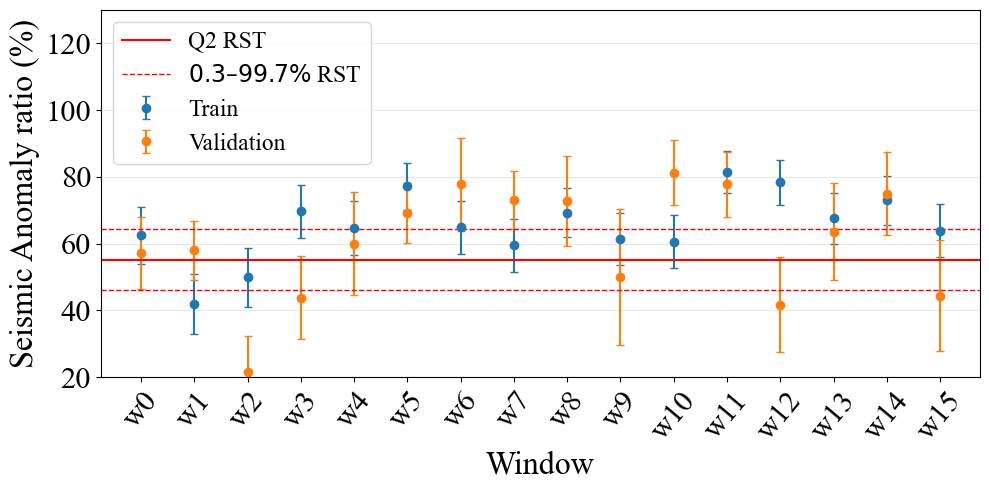

     99.7_All  0.3_All  q2_All
key                           
48       64.5     46.0    55.0


C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y  = float(t['q2_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e1 = float(t['0.3_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e2 = float(t['99.7_All'])


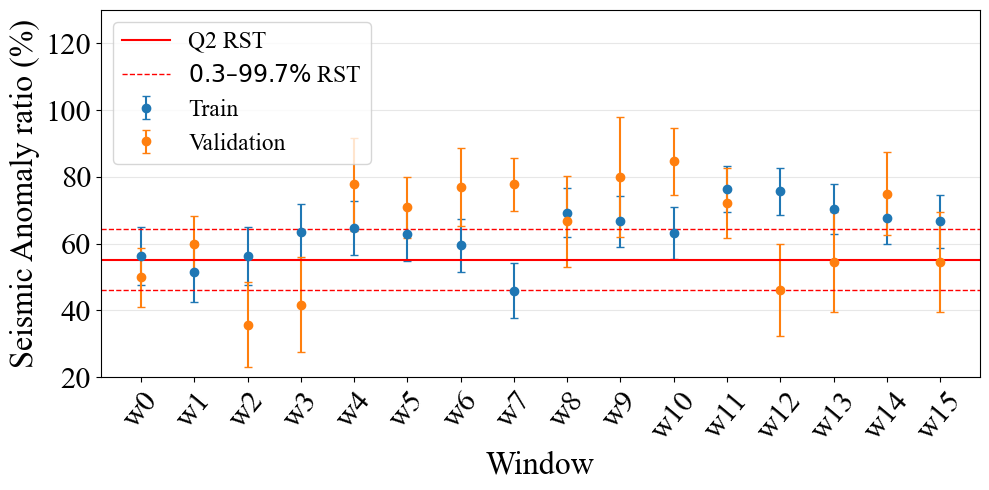

     99.7_All  0.3_All  q2_All
key                           
48       64.5     46.0    55.0


C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y  = float(t['q2_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e1 = float(t['0.3_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e2 = float(t['99.7_All'])


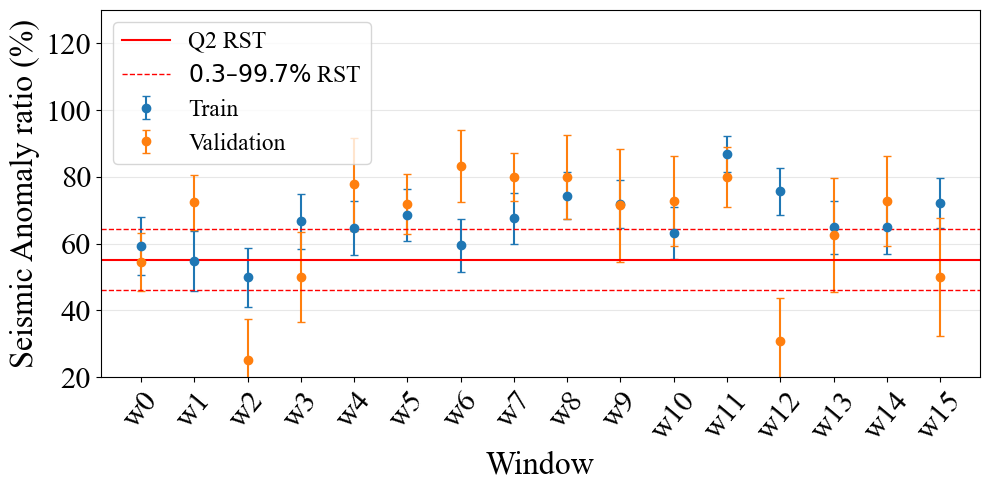

     99.7_All  0.3_All  q2_All
key                           
48       64.5     46.0    55.0


C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y  = float(t['q2_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e1 = float(t['0.3_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e2 = float(t['99.7_All'])


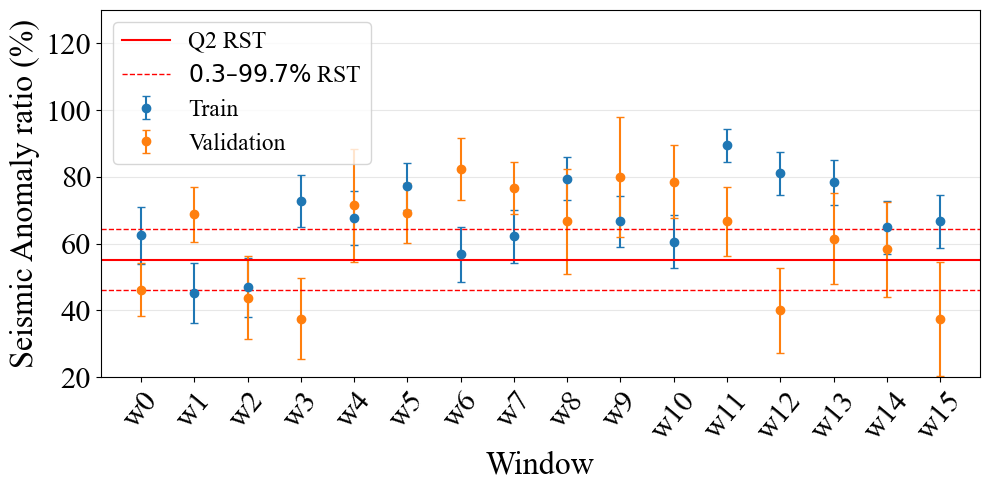

     99.7_All  0.3_All  q2_All
key                           
48       64.5     46.0    55.0


C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y  = float(t['q2_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e1 = float(t['0.3_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e2 = float(t['99.7_All'])


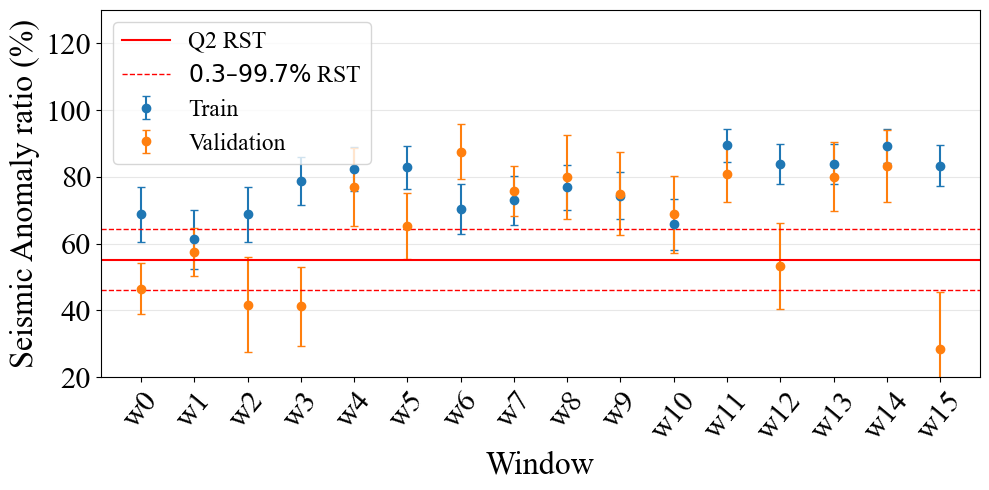

     99.7_All  0.3_All  q2_All
key                           
48       64.5     46.0    55.0


C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y  = float(t['q2_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e1 = float(t['0.3_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e2 = float(t['99.7_All'])


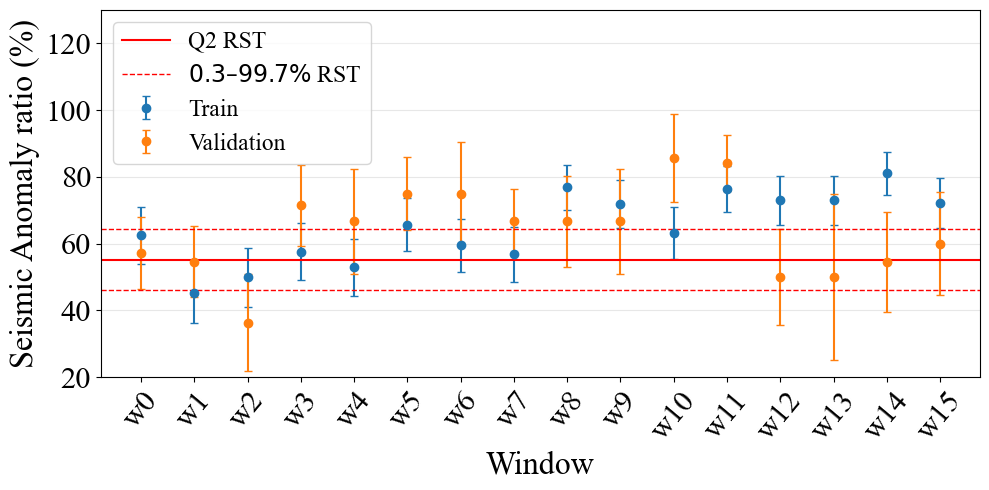

     99.7_All  0.3_All  q2_All
key                           
48       64.5     46.0    55.0


C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y  = float(t['q2_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e1 = float(t['0.3_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e2 = float(t['99.7_All'])


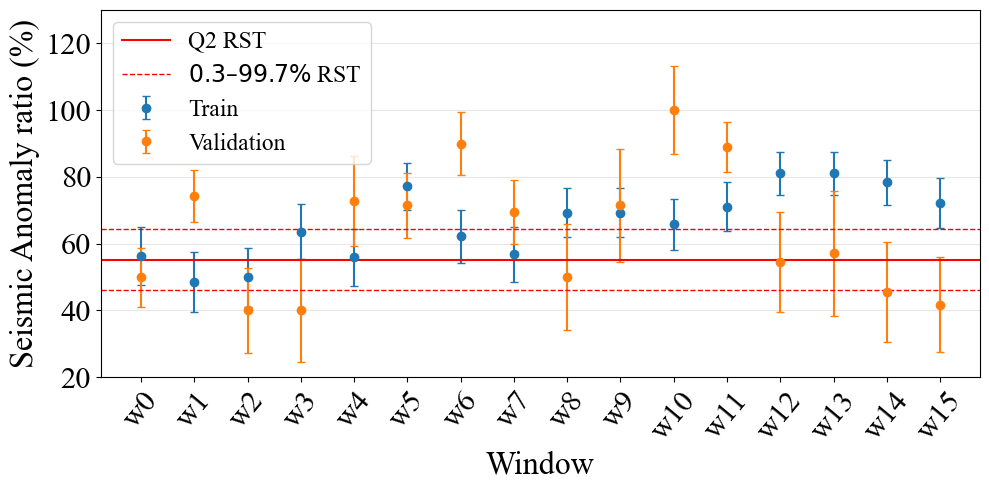

     99.7_All  0.3_All  q2_All
key                           
48       64.5     46.0    55.0


C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y  = float(t['q2_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e1 = float(t['0.3_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e2 = float(t['99.7_All'])


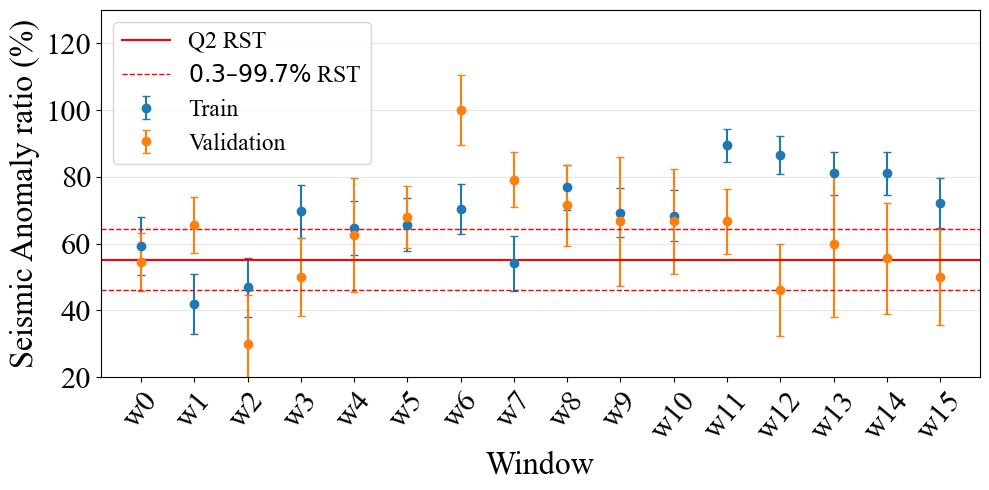

     99.7_All  0.3_All  q2_All
key                           
48       64.5     46.0    55.0


C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y  = float(t['q2_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e1 = float(t['0.3_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e2 = float(t['99.7_All'])


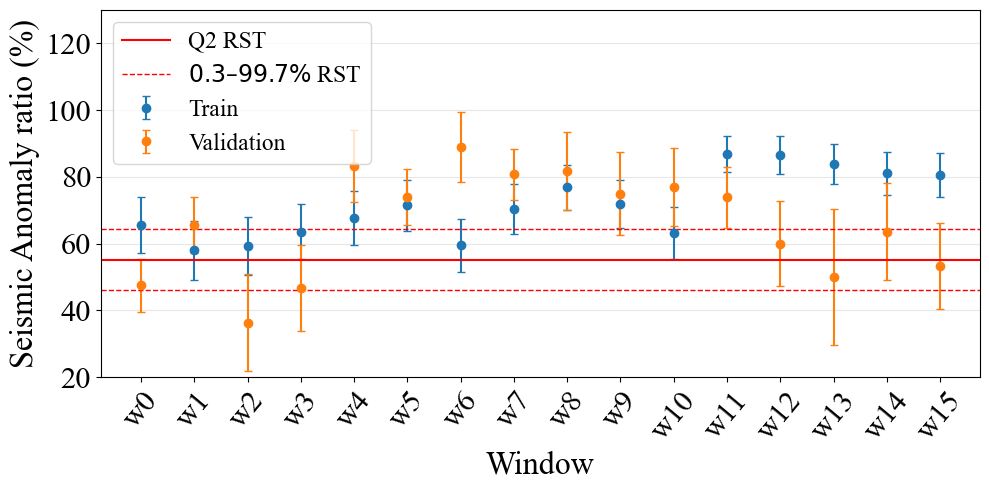

     99.7_All  0.3_All  q2_All
key                           
48       64.5     46.0    55.0


C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y  = float(t['q2_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e1 = float(t['0.3_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3812683241.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  e2 = float(t['99.7_All'])


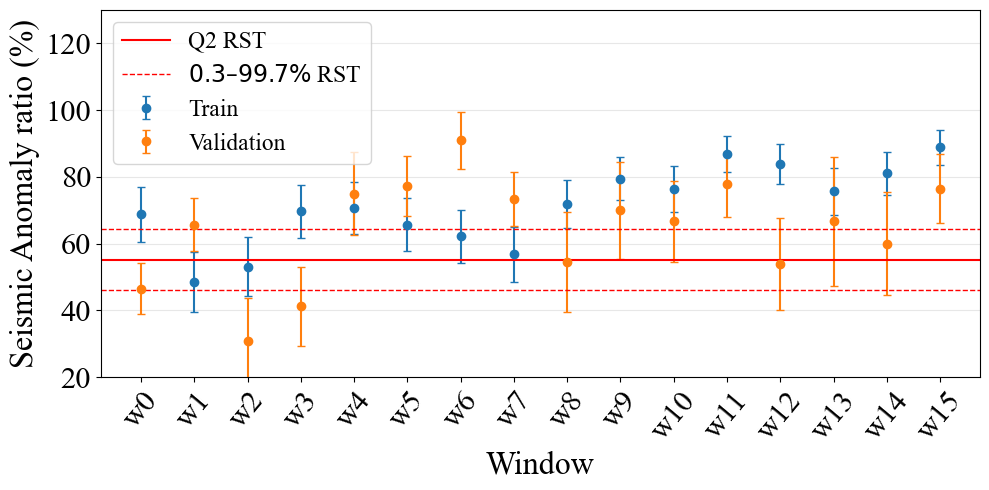

In [13]:

# --- loop over each Naming in hyperparams ---
for i in range(len(df_hparams)):
    # print(df_hparams.loc[i, 'Naming'])
    m = df_hparams['Naming'][i]
    nm = m.split('_')[-1]
  
    file_path  = fr"{csv_file}\Retrain_result_Hp_B-{m}.csv"
    if not os.path.exists(file_path):
        print(f"⚠️ File not found for {m}: {file_path}")
        continue

    df = pd.read_csv(file_path)
    tw = df_hparams['tw'][i]
    # print(df)
    if "window" not in df.columns:
        df = df.copy()
        df["window"] = (np.arange(len(df)) // 2).astype(int)

    # Now call your plotting functions
    plot_ratio_errorbars_combined(df, tw,'all',f'{nm}',   fr"{output_dir}\ratio_all-{m}.png")


## Function: `plot_anomaly_bars`

**What it does:** creates stacked bar plots showing the total detected anomalies split into seismic and non-seismic components for train and validation windows.

**Main use:** this helps compare how many anomalies are being classified as earthquake-associated versus non-associated in each rolling window.

**Inputs:**
- `df`: result dataframe for one model.
- `category`: `"all"` uses `anomalies` and `agg_value`; `"quiet"` uses `anomalies_sc` and `agg_value_sc`.
- `name`: model label used in the plot title.
- `

**Outputs:** displays a stacked anomaly-count bar plot.


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib import rcParams

def plot_anomaly_bars(df, category, name, outpath):
    """
    Stacked bar plot of total anomalies split into seismic vs non-seismic,
    for train and val, per window.

    - category: "all"   → use anomalies / agg_value
                "quiet" → use anomalies_sc / agg_value_sc
    """

    # ---- Global font setting ----
    rcParams['font.family'] = 'Times New Roman'

    tr = df[df["split"].str.lower() == "train"].sort_values("window")
    va = df[df["split"].str.lower() == "val"].sort_values("window")

    # Choose variables depending on category
    if category.lower() == "all":
        tot_tr = tr["anomalies"].to_numpy(float)
        tot_va = va["anomalies"].to_numpy(float)
        ratio_tr = tr["agg_value"].to_numpy(float) / 100.0  # ratios in %
        ratio_va = va["agg_value"].to_numpy(float) / 100.0
        title_suffix = "All data"
    else:
        tot_tr = tr["anomalies_sc"].to_numpy(float)
        tot_va = va["anomalies_sc"].to_numpy(float)
        ratio_tr = tr["agg_value_sc"].to_numpy(float) / 100.0
        ratio_va = va["agg_value_sc"].to_numpy(float) / 100.0
        title_suffix = "Quiet"

    # --- Compute seismic and non-seismic components ---
    seis_tr = tot_tr * ratio_tr
    non_tr  = tot_tr - seis_tr
    seis_va = tot_va * ratio_va
    non_va  = tot_va - seis_va

    # --- Plot setup ---
    x = np.arange(len(tr))
    width = 0.35
    hatch_pat = "//"

    fig, ax = plt.subplots(figsize=(12, 5))

    # --- TRAIN (royalblue) ---
    ax.bar(
        x - width/2, seis_tr, width,
        color="tab:blue", edgecolor="k",
        hatch=hatch_pat
    )
    ax.bar(
        x - width/2, non_tr, width,
        bottom=seis_tr,
        color="tab:blue", edgecolor="k"
    )

    # --- VALIDATION (dark orange) ---
    dark_orange = "#FF8C00"
    ax.bar(
        x + width/2, seis_va, width,
        color=dark_orange, edgecolor="k",
        hatch=hatch_pat
    )
    ax.bar(
        x + width/2, non_va, width,
        bottom=seis_va,
        color=dark_orange, edgecolor="k"
    )

    # --- Axis setup (same thesis standard) ---
    ax.set_xlabel("Window", fontsize=20)
    ax.set_ylabel("Anomaly Count", fontsize=20)
    ax.set_title(f"Model {name}", fontsize=22)

    # Window labels as w0, w1, ...
    win_ticks = tr["window"].to_numpy(int)
    ax.set_xticks(x)
    ax.set_xticklabels([f"w{w}" for w in win_ticks], fontsize=18)

    ax.tick_params(axis="y", labelsize=18)

    # --- Custom legend (same content, formatted) ---
    ax.legend(
        handles=[
            Patch(facecolor='tab:blue', edgecolor="k", hatch=hatch_pat, label="Train - Seismic"),
            Patch(facecolor='tab:blue', edgecolor="k", label="Train - Non-seismic"),
            Patch(facecolor=dark_orange, edgecolor="k", hatch=hatch_pat, label="Val - Seismic"),
            Patch(facecolor=dark_orange, edgecolor="k", label="Val - Non-seismic"),
        ],
        ncol=2,
        frameon=False,
        loc="upper left",
        fontsize=12
    )

    plt.tight_layout()
    # plt.savefig(outpath, dpi=600)
    plt.show()


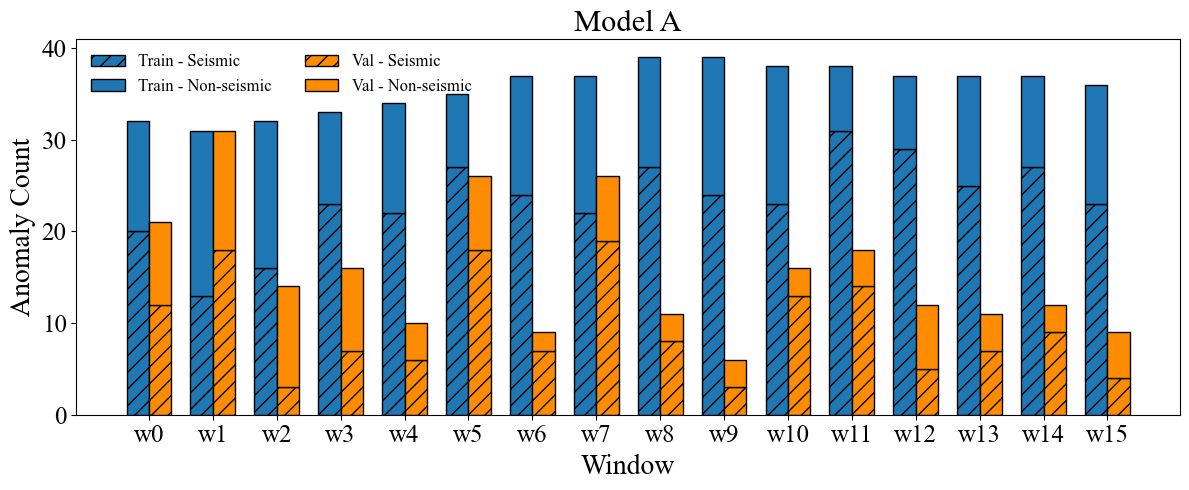

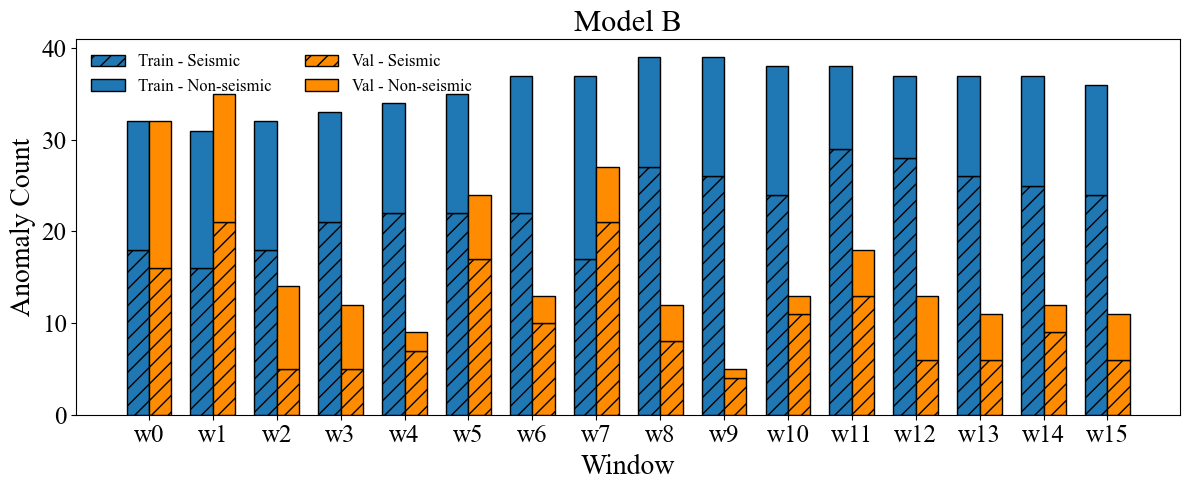

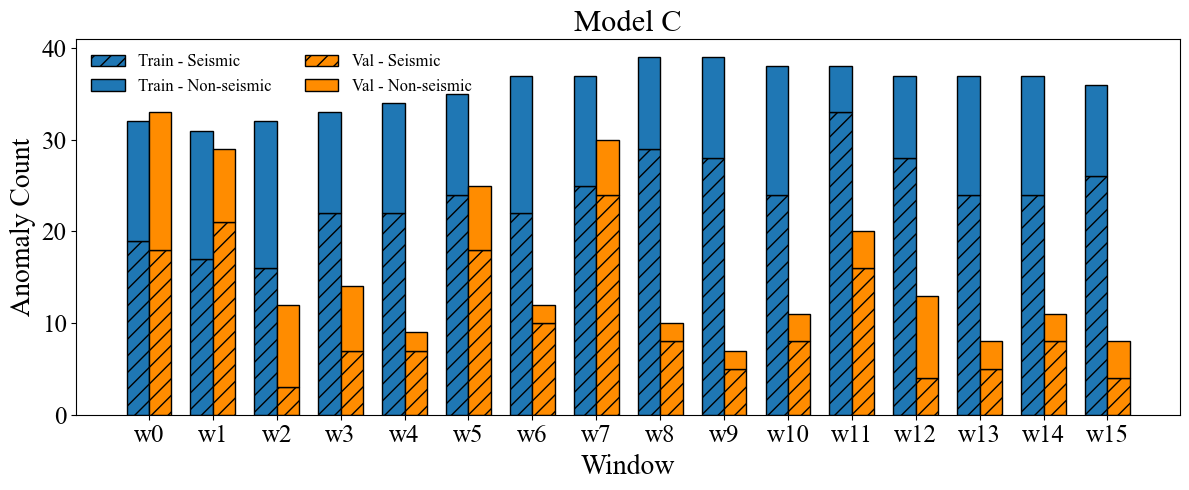

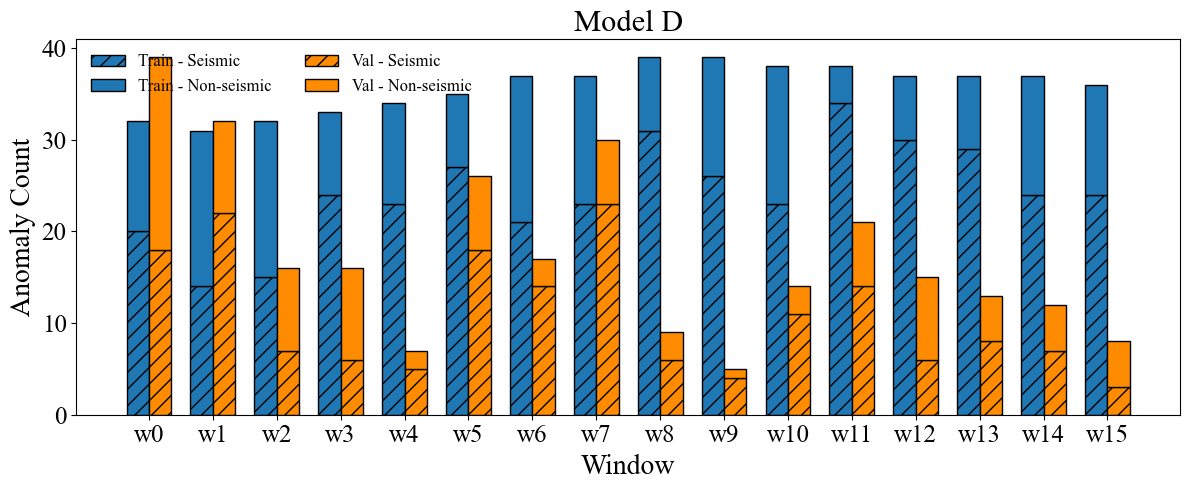

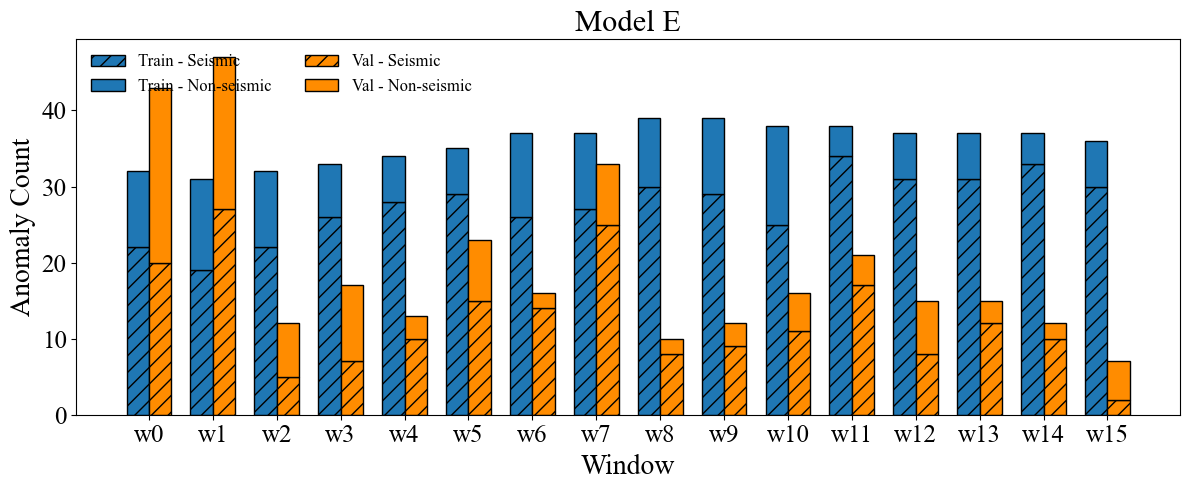

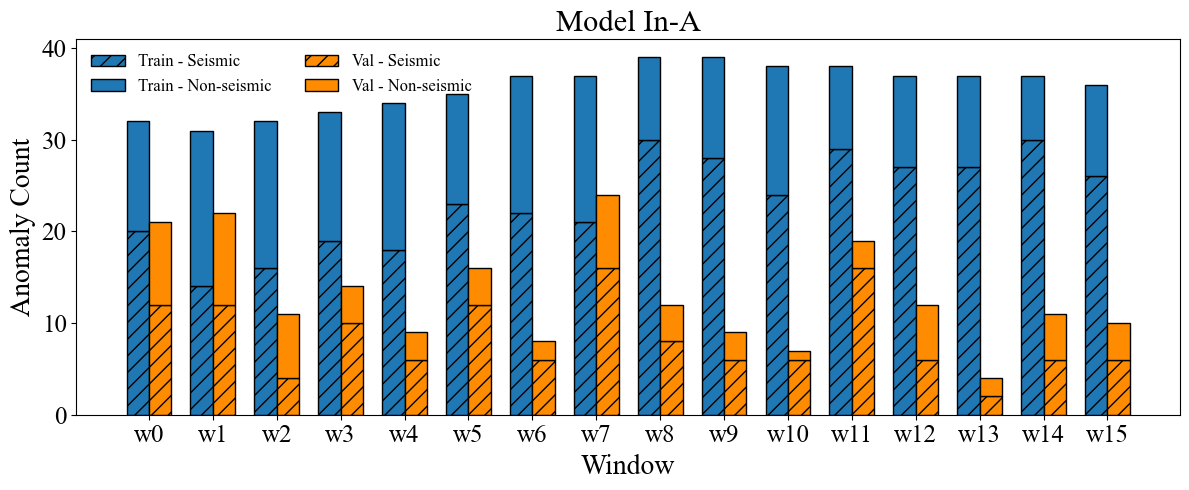

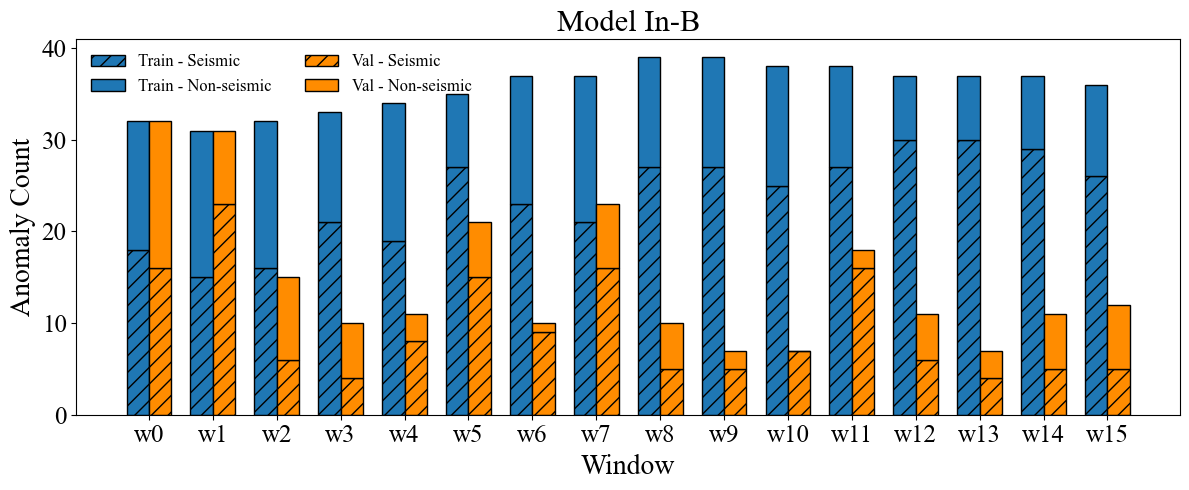

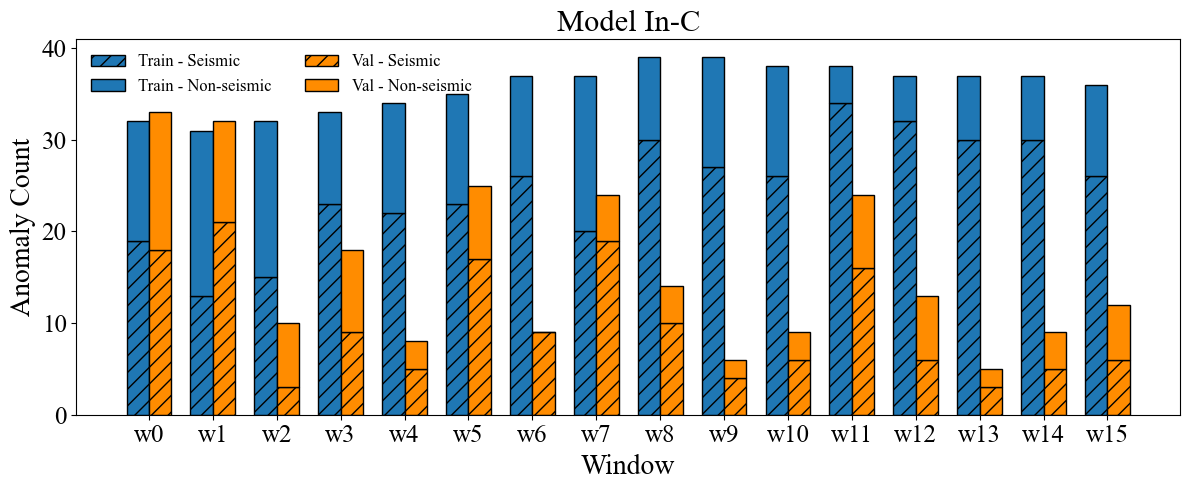

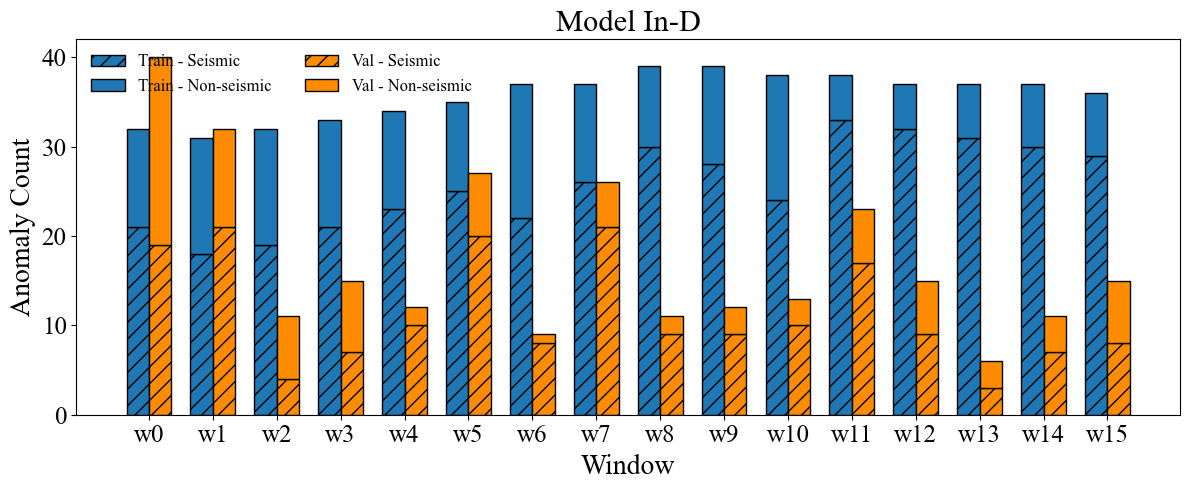

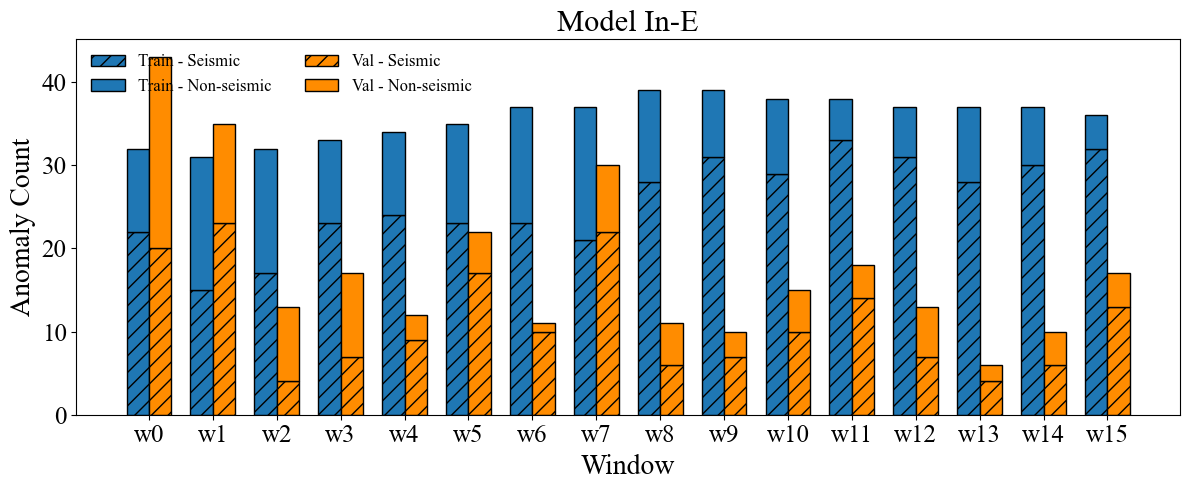

In [15]:

# --- loop over each Naming in hyperparams ---
for i in range(len(df_hparams)):
    # print(df_hparams.loc[i, 'Naming'])
    m = df_hparams['Naming'][i]
    nm = m.split('_')[-1]
    file_path  = fr"{csv_file}\Retrain_result_Hp_B-{m}.csv"
    if not os.path.exists(file_path):
        print(f"⚠️ File not found for {m}: {file_path}")
        continue

    df = pd.read_csv(file_path)
    tw = df_hparams['tw'][i]
    # print(df)
    if "window" not in df.columns:
        df = df.copy()
        df["window"] = (np.arange(len(df)) // 2).astype(int)

    # Now call your plotting functions
    plot_anomaly_bars(df,'all',f'{nm}',   fr"{output_dir}\precision_all-{m}.png")


## Function: `generate_windows`

**What it does:** generates rolling train/validation date windows between a start date and an end date.

**Main use:** this defines the time ranges used for rolling-window retraining and validation.

**Inputs:**
- `start_date`: first date of the rolling-window scheme.
- `end_date`: final date limit.
- `train_months`: length of each training period in months.
- `val_months`: length of each validation period in months.

**Outputs:** returns a list of dictionaries. Each dictionary contains `train_start`, `train_end`, `val_start`, and `val_end`.

**Note:** the current function advances the rolling window by 3 months after each iteration.


In [16]:
# Generate the rolling windows for 2005–2010
def generate_windows(start_date, end_date, train_months, val_months):
    """
    Generate train/val windows from start to end date.
    Each window: train_months + val_months
    """
    windows = []
    current = pd.to_datetime(start_date)

    while current + pd.DateOffset(months=train_months + val_months) < pd.to_datetime(end_date):
        train_start = current
        train_end   = current + pd.DateOffset(months=train_months)
        val_end     = train_end + pd.DateOffset(months=val_months)

        windows.append({
            "train_start": train_start,
            "train_end": train_end,
            "val_start": train_end,
            "val_end": val_end
        })

        # slide window forward (3 months)
        current = current + pd.DateOffset(months=3)

    return windows

# Define windows: 3m train + 3m val = 6 months per window
windows_train = generate_windows(
    start_date="2005-01-01 00:00:00",
    end_date="2010-02-01 00:00:00",
    train_months=12,
    val_months=3
)


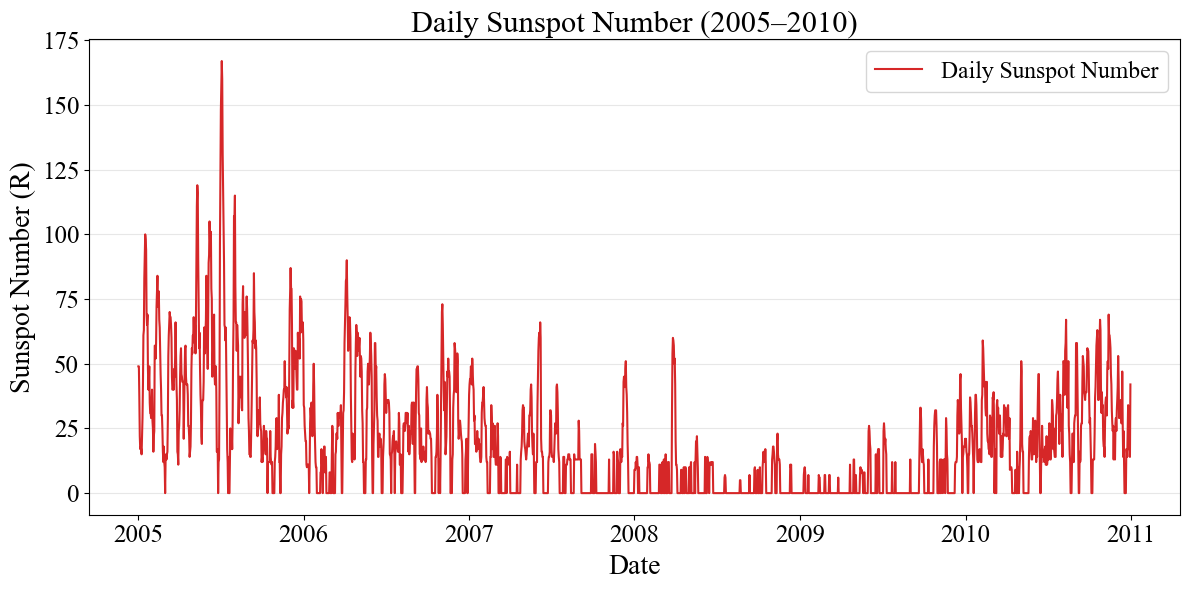

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ---- Global font setting ----
rcParams['font.family'] = 'Times New Roman'

# Load the file
file_path = r"C:\Users\mbabu\Downloads\SN_d_tot_V2.0.csv"
df = pd.read_csv(file_path, sep=";", header=None)

# Assign column names
df.columns = [
    "year", "month", "day", "decimal_year",
    "SNvalue", "SNerror", "Nb_observations", "indicator"
]

# Convert to datetime
df["date"] = pd.to_datetime(df[["year", "month", "day"]])

# Filter years 2005–2010
df_filtered = df[(df["year"] >= 2005) & (df["year"] <= 2010)]

# ---- Plot ----
plt.figure(figsize=(12, 6))

plt.plot(
    df_filtered["date"],
    df_filtered["SNvalue"],
    label="Daily Sunspot Number",
    color="tab:red"
)

# Labels and title
plt.xlabel("Date", fontsize=20)
plt.ylabel("Sunspot Number (R)", fontsize=20)
plt.title("Daily Sunspot Number (2005–2010)", fontsize=22)

# Ticks
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Legend
plt.legend(fontsize=17)

# Grid (same subtle style)
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
# plt.savefig(f'{output_dir}\sunspot.png',dpi=600)
plt.show()


## Functions: `aggregate_sunspots_by_window` and `plot_ratio_with_sunspots`

### `aggregate_sunspots_by_window`

**What it does:** calculates the mean sunspot number separately for the training and validation period of each rolling window.

**Inputs:**
- `df_sunspots`: sunspot dataframe with at least `date` and `SNvalue` columns.
- `windows`: rolling-window date ranges, usually created by `generate_windows`.

**Outputs:** two NumPy arrays: average train-period sunspot values and average validation-period sunspot values.

### `plot_ratio_with_sunspots`

**What it does:** plots stacked anomaly counts and overlays the average sunspot number for the matching train/validation windows.

**Main use:** this helps visually check whether anomaly-count behaviour follows solar-cycle/sunspot variation.

**Inputs:**
- `df`: model result dataframe.
- `tw`: temporal window value.
- `category`: `"all"` or quiet/storm-corrected mode.
- `name`: model label.
- `outpath`: intended output path. Saving is currently commented out.
- `df_sunspots`: sunspot dataframe.
- `windows`: rolling-window date ranges.

**Outputs:** displays a combined anomaly-count and sunspot plot.


In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from matplotlib import rcParams

def aggregate_sunspots_by_window(df_sunspots, windows):
    avg_train, avg_val = [], []
    for w in windows:
        mask_train = (df_sunspots["date"] >= w["train_start"]) & (df_sunspots["date"] < w["train_end"])
        mask_val   = (df_sunspots["date"] >= w["val_start"])   & (df_sunspots["date"] < w["val_end"])

        avg_train.append(df_sunspots.loc[mask_train, "SNvalue"].mean())
        avg_val.append(df_sunspots.loc[mask_val, "SNvalue"].mean())

    return np.array(avg_train), np.array(avg_val)


def plot_ratio_with_sunspots(df, tw, category, name, outpath, df_sunspots, windows):

    # ---- Global font ----
    rcParams['font.family'] = 'Times New Roman'

    # ---- anomaly data ----
    tr = df[df["split"].str.lower() == "train"].sort_values("window")
    va = df[df["split"].str.lower() == "val"].sort_values("window")

    if category.lower() == "all":
        tot_tr = tr["anomalies"].to_numpy(float)
        tot_va = va["anomalies"].to_numpy(float)
        ratio_tr = tr["agg_value"].to_numpy(float) / 100.0
        ratio_va = va["agg_value"].to_numpy(float) / 100.0
    else:
        tot_tr = tr["anomalies_sc"].to_numpy(float)
        tot_va = va["anomalies_sc"].to_numpy(float)
        ratio_tr = tr["agg_value_sc"].to_numpy(float) / 100.0
        ratio_va = va["agg_value_sc"].to_numpy(float) / 100.0

    # --- Compute components ---
    seis_tr = tot_tr * ratio_tr
    non_tr  = tot_tr - seis_tr
    seis_va = tot_va * ratio_va
    non_va  = tot_va - seis_va

    # --- Plot setup ---
    x = np.arange(len(tr))
    width = 0.35
    hatch_pat = "//"

    fig, ax = plt.subplots(figsize=(12, 5))

    # --- TRAIN bars (tab:blue) ---
    ax.bar(
        x - width/2, seis_tr, width,
        color="tab:blue", edgecolor="k",
        hatch=hatch_pat
    )
    ax.bar(
        x - width/2, non_tr, width,
        bottom=seis_tr,
        color="tab:blue", edgecolor="k"
    )

    # --- VALIDATION bars (tab:orange) ---
    ax.bar(
        x + width/2, seis_va, width,
        color="tab:orange", edgecolor="k",
        hatch=hatch_pat
    )
    ax.bar(
        x + width/2, non_va, width,
        bottom=seis_va,
        color="tab:orange", edgecolor="k"
    )

    # ---- Sunspot averages (same axis) ----
    avg_train, avg_val = aggregate_sunspots_by_window(df_sunspots, windows)
    ax.plot(x, avg_train, marker="s", color="tab:blue", label="Train – Sunspots")
    ax.plot(x, avg_val, marker="s", color="tab:orange", label="Val – Sunspots")

    # ---- Axis formatting ----
    ax.set_xlabel("Window", fontsize=25)
    ax.set_ylabel("Count", fontsize=25)
    ax.set_title(f"Model {name}", fontsize=25)

    ax.set_xticks(x)
    ax.set_xticklabels([f"w{int(w)}" for w in tr["window"].to_numpy(int)],
                   rotation=45, ha='right')
    ax.tick_params(axis='both', labelsize=23)

    ax.set_ylim(0,60)

    # ---- Legend (unified) ----
    ax.legend(
        handles=[
            Patch(facecolor="tab:blue", edgecolor="k", hatch=hatch_pat, label="Train – Seismic"),
            Patch(facecolor="tab:blue", edgecolor="k", label="Train – Non-seismic"),
            Patch(facecolor="tab:orange", edgecolor="k", hatch=hatch_pat, label="Val – Seismic"),
            Patch(facecolor="tab:orange", edgecolor="k", label="Val – Non-seismic"),
            plt.Line2D([0], [0], color="tab:blue", marker="s", label="Train – Sunspots"),
            plt.Line2D([0], [0], color="tab:orange", marker="s", label="Val – Sunspots"),
        ],
        ncol=2,
        frameon=False,
        fontsize=17,
        loc="upper right"
    )

    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    # plt.savefig(outpath, dpi=600)
    # plt.savefig(outpath, dpi=600)
    plt.show()


In [19]:
output_dir

'C:\\PROJECT-DEMETER\\Paper1\\Plots\\SW22TW48'

In [20]:

storm_data['Datetime'] = pd.to_datetime(storm_data['Datetime'])

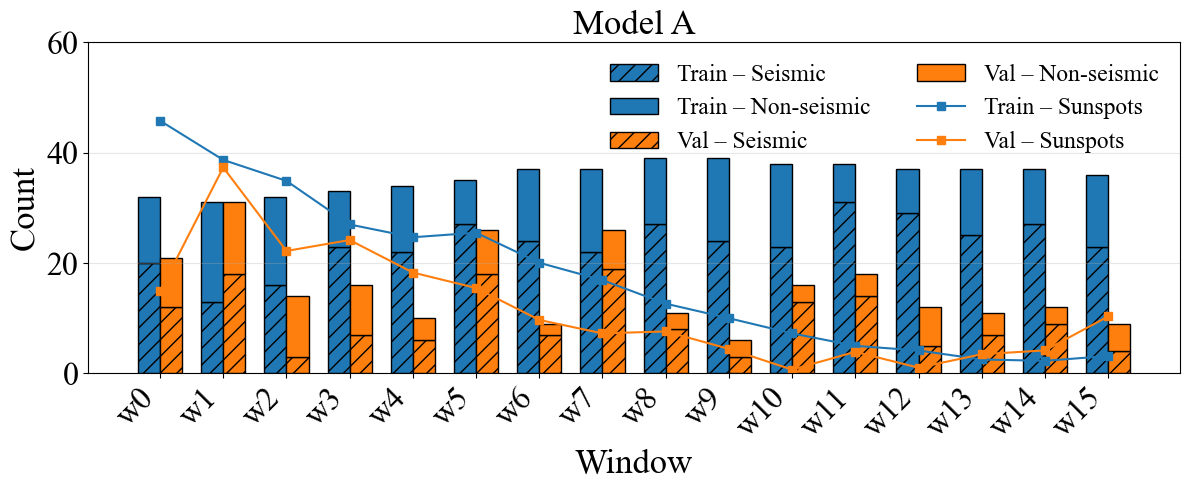

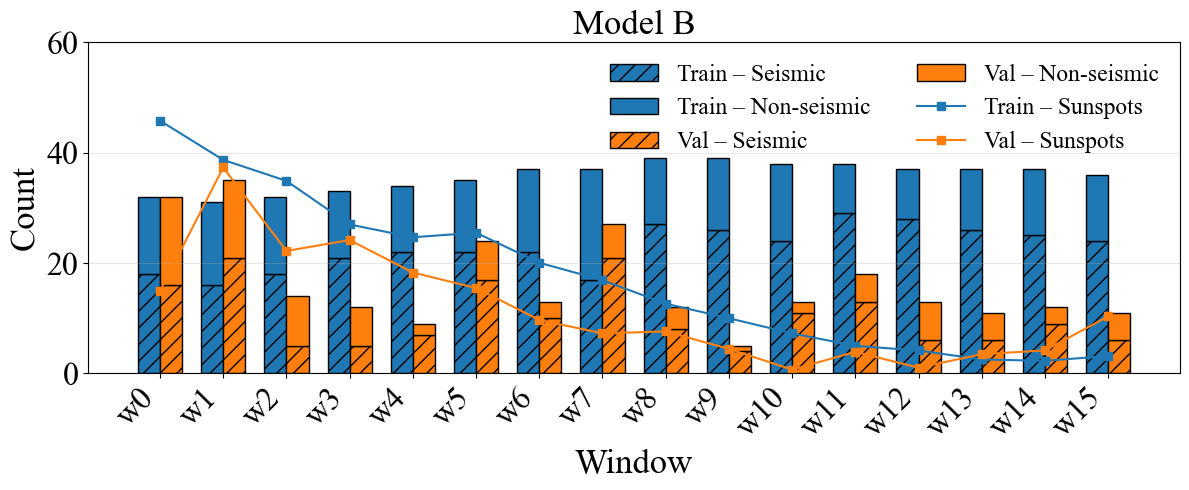

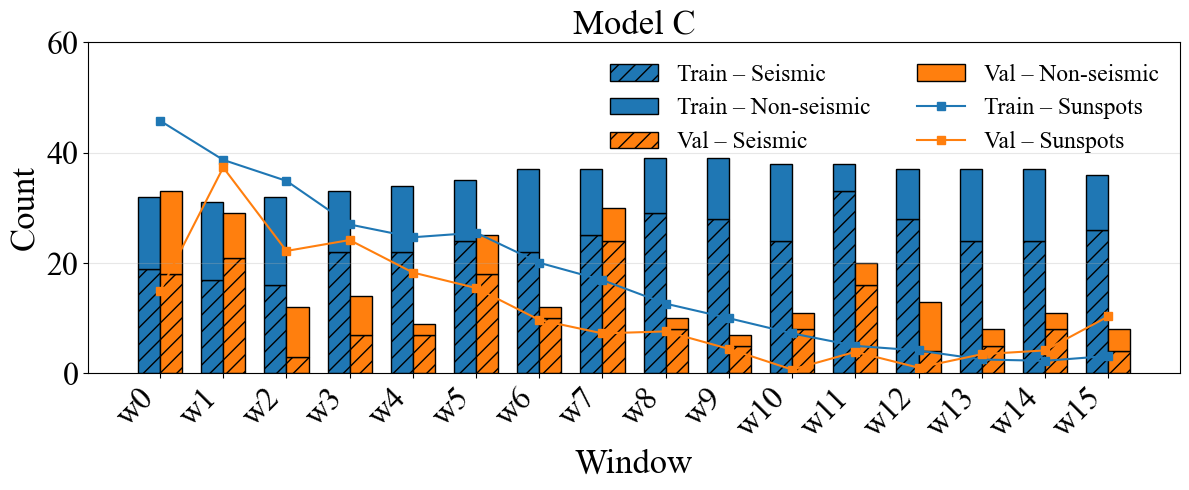

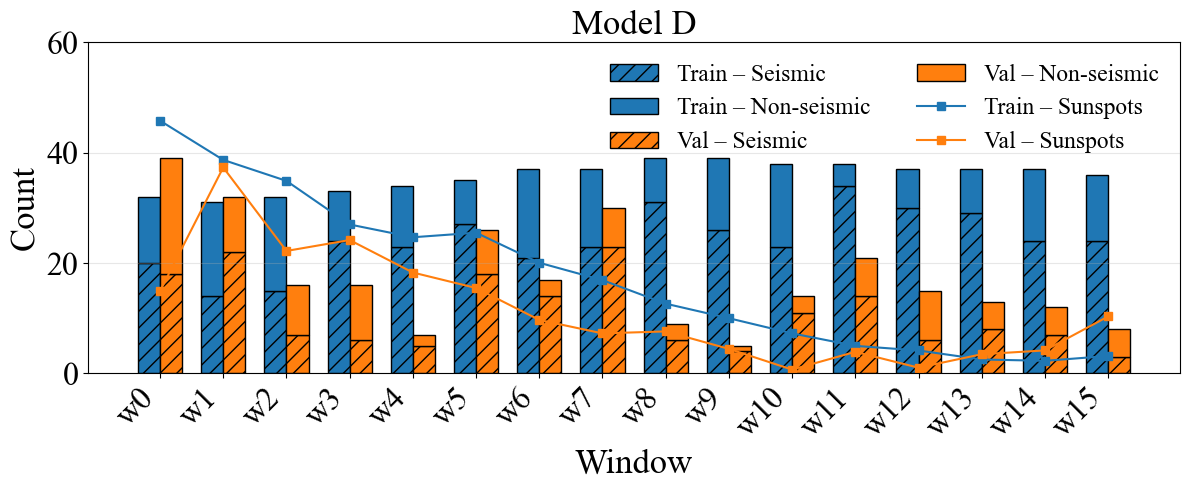

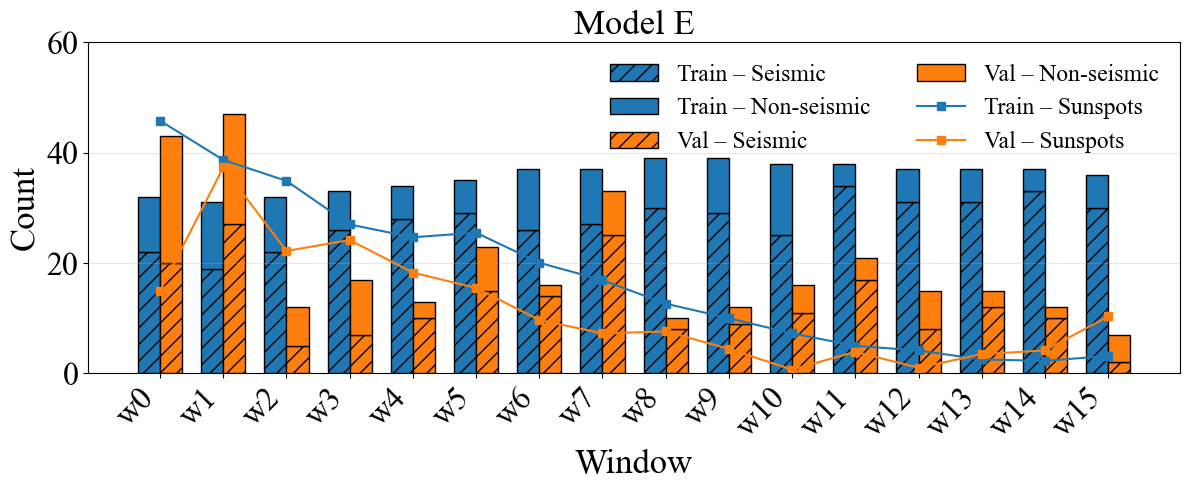

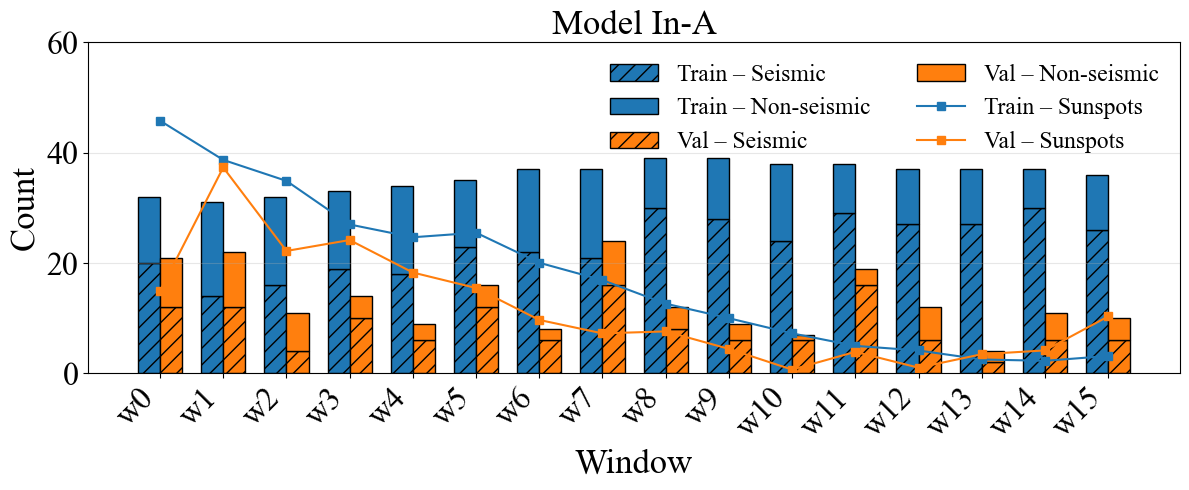

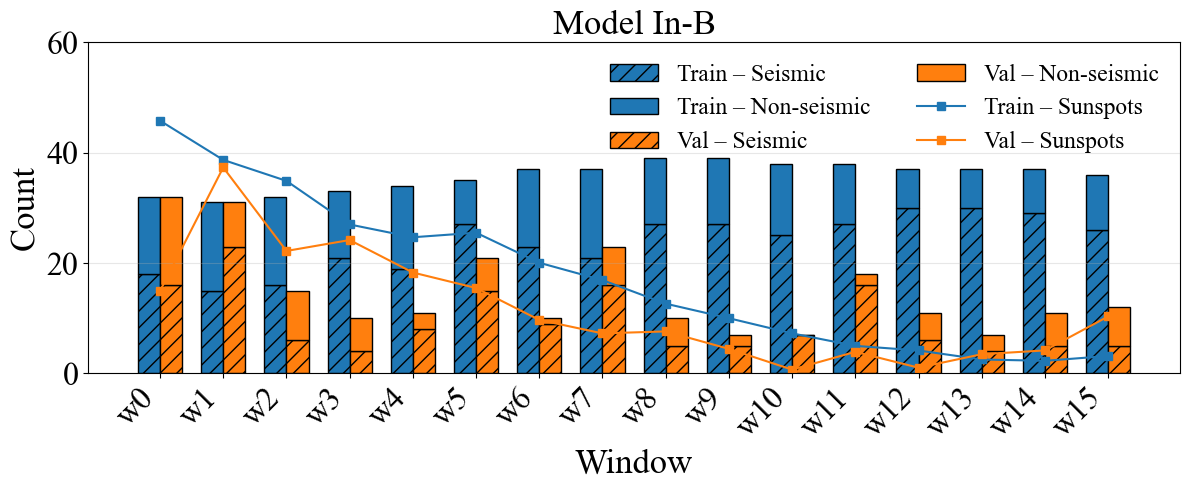

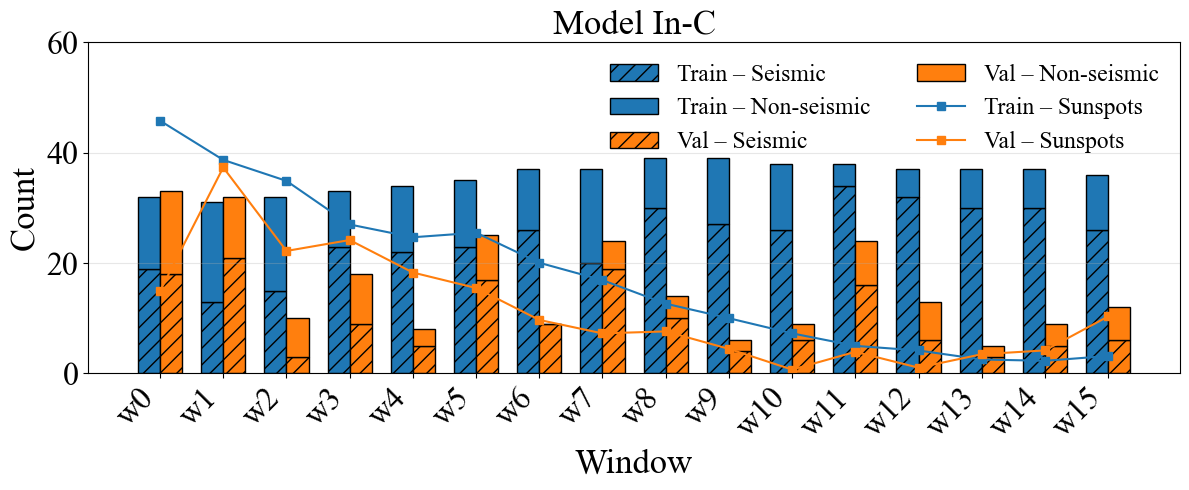

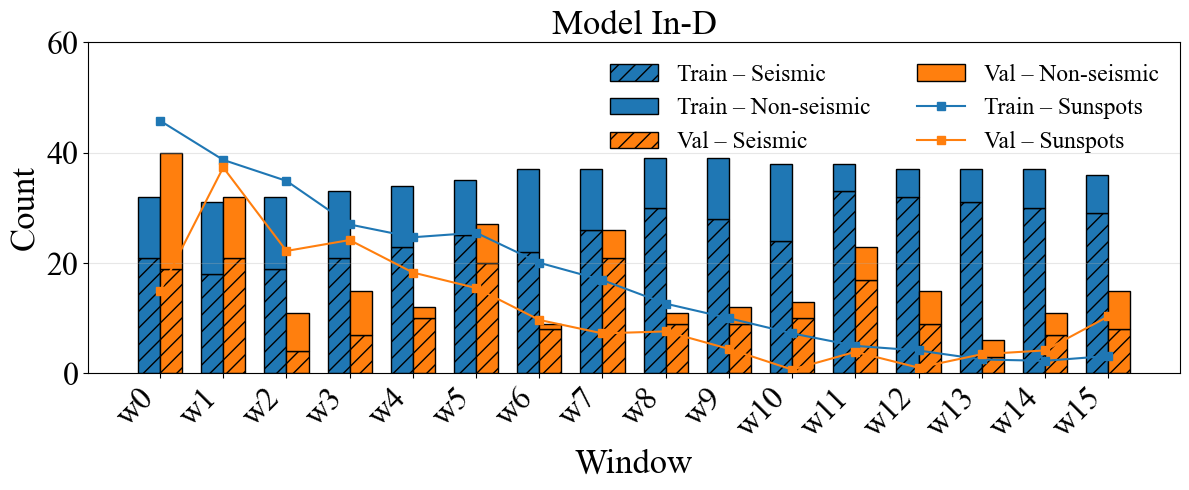

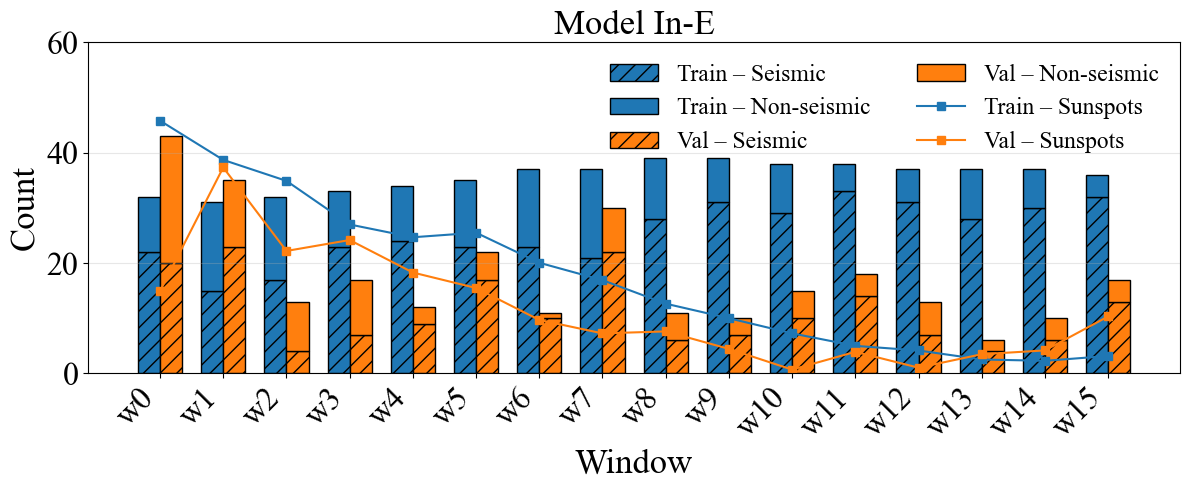

In [21]:
for i in range(len(df_hparams)):
    # print(df_hparams.loc[i, 'Naming'])
    m = df_hparams['Naming'][i]
    n = m.split("_")[-1]
    # file_path  = fr"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Cluster\Reslut_csv\result_Hp_{m}.csv"

    file_path = fr"{csv_file}\Retrain_result_Hp_B-{m}.csv"
    if not os.path.exists(file_path):
        print(f"⚠️ File not found for {m}: {file_path}")
        continue

    df = pd.read_csv(file_path)
    tw = df_hparams['tw'][i]
    # print(df)
    if "window" not in df.columns:
        df = df.copy()
        df["window"] = (np.arange(len(df)) // 2).astype(int)

    # Now call your plotting functions
    plot_ratio_with_sunspots(df, tw,'all', n,   fr"C:\PROJECT-DEMETER\Paper1\Plots\Remote Sensing\sw22_tw48\Sunspotratio_all_{m}.png",df_filtered,windows=windows_train)
    # plot_ratio_with_sunspots(df,  tw,'quiet',f"quiet- model_{m}", fr"{output_dir}\ratio_quiet_{m}.png",df_filtered,windows=windows_train)

In [22]:
output_dir

'C:\\PROJECT-DEMETER\\Paper1\\Plots\\SW22TW48'

In [23]:
import pandas as pd
import numpy as np
import os

for i in range(len(df_hparams)):
    m = df_hparams['Naming'][i]
    file_path = fr"{csv_file}\Retrain_result_Hp_B-{m}.csv"
    new_fp = fr"{csv_file}\Accuracy_Hp-{m}.csv"


    if not os.path.exists(file_path):
        print(f"⚠️ File not found for {m}: {file_path}")
        continue

    df = pd.read_csv(file_path)

    # Ensure window column exists
    if "window" not in df.columns:
        df = df.copy()
        df["window"] = (np.arange(len(df)) // 2).astype(int)

    # --- Step 1: build ground-truth dict for all windows ---
    gt_counts = {}  # {(window, split): anomaly_count}
    for window in range(0, 16):
        train_n = pd.read_csv(
            f"C:\\PROJECT-DEMETER\\Demeter_Retrain\\output_base\\Bg_window_data\\summary_df_train_30D-{sw}SW-tw{tw}_w{window}.csv"
        )
        val_n = pd.read_csv(
            f"C:\\PROJECT-DEMETER\\Demeter_Retrain\\output_base\\Bg_window_data\\summary_df_val_30D-{sw}SW-tw{tw}_w{window}.csv"
        )

        gt_counts[(window, "Train")] = np.sum(train_n['label'])
        gt_counts[(window, "Val")]   = np.sum(val_n['label'])

    # --- Step 2: compute precision & recall per row ---
    df["precision"] = df["agg_value"] / 100

    tp = df["agg_value"] / 100 * df["anomalies"]

    recalls = []
    for idx, row in df.iterrows():
        key = (row["window"], row["split"])
        if key in gt_counts and gt_counts[key] > 0:
            recalls.append(tp.loc[idx] / gt_counts[key])
        else:
            recalls.append(np.nan)
    df["recall"] = recalls

    # --- Step 3: save back ---
    df.to_csv(new_fp, index=False)
    print(f"✅ Updated {file_path}")


✅ Updated C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\Retrain_result_Hp_B-tw48-30dBG_A.csv
✅ Updated C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\Retrain_result_Hp_B-tw48-30dBG_B.csv
✅ Updated C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\Retrain_result_Hp_B-tw48-30dBG_C.csv
✅ Updated C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\Retrain_result_Hp_B-tw48-30dBG_D.csv
✅ Updated C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\Retrain_result_Hp_B-tw48-30dBG_E.csv
✅ Updated C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\Retrain_result_Hp_B-tw48-30dBG_In-A.csv
✅ Updated C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\Retrain_result_Hp_B-tw48-30dBG_In-B.csv
✅ Updated C:\PROJECT-DEMETER

In [24]:
import pandas as pd
import numpy as np
import glob
import os

accuracy_files = glob.glob(rf"{csv_file}\Accuracy_Hp-*.csv")

all_models_summary = []

for fp in accuracy_files:
    model_name = os.path.basename(fp).replace("Accuracy_Hp-", "").replace(".csv", "")
    df = pd.read_csv(fp)

    # True positives per row
    df["tp"] = (df["precision"] * df["anomalies"]).astype(float)

    for split in ["Train", "Val"]:
        df_s = df[df["split"] == split]

        if df_s.empty:
            continue

        # ---- average counts across windows ----
        avg_anomalies = df_s["anomalies"].mean()
        avg_tp        = df_s["tp"].mean()
        # avg_gt        = df_s["agg_total_eq"].mean()
        avg_recall     = df_s["recall"].mean()

        # ---- recompute metrics from averaged counts ----
        avg_precision = df_s["precision"].mean()
        # avg_recall    = avg_tp / avg_gt if avg_gt > 0 else np.nan

        all_models_summary.append({
            "model": model_name,
            "split": split,
            "avg_anomalies": avg_anomalies,
            "avg_tp": avg_tp,
            # "avg_gt_counts": avg_gt,
            "avg_precision": avg_precision,
            "avg_recall": avg_recall
        })

# Final summary dataframe
df_summary = pd.DataFrame(all_models_summary)

# Optional: save
out_fp = rf"{csv_file}\Model_Average_Performance.csv"
df_summary.to_csv(out_fp, index=False)

df_summary


,model,split,avg_anomalies,avg_tp,avg_precision,avg_recall
0,tw48-30dBG_A,Train,35.7500,23.5000,0.653742,0.024490
1,tw48-30dBG_A,Val,15.5000,9.5625,0.604359,0.039224
2,tw48-30dBG_B,Train,35.7500,22.8125,0.635168,0.023834
3,tw48-30dBG_B,Val,16.3125,10.3125,0.640276,0.042585
4,tw48-30dBG_C,Train,35.7500,23.9375,0.665604,0.024942
5,tw48-30dBG_C,Val,15.7500,10.3750,0.647014,0.043369
6,tw48-30dBG_D,Train,35.7500,24.2500,0.673823,0.025225
7,tw48-30dBG_D,Val,17.5000,10.7500,0.615693,0.044617
8,tw48-30dBG_E,Train,35.7500,27.6250,0.770417,0.028925
9,tw48-30dBG_E,Val,19.5000,12.5000,0.651338,0.052110


In [25]:
import pandas as pd

summary_fp = rf"{csv_file}\Model_Average_Performance.csv"
df = pd.read_csv(summary_fp)

df.head()


,model,split,avg_anomalies,avg_tp,avg_precision,avg_recall
0,tw48-30dBG_A,Train,35.7500,23.5000,0.653742,0.024490
1,tw48-30dBG_A,Val,15.5000,9.5625,0.604359,0.039224
2,tw48-30dBG_B,Train,35.7500,22.8125,0.635168,0.023834
3,tw48-30dBG_B,Val,16.3125,10.3125,0.640276,0.042585
4,tw48-30dBG_C,Train,35.7500,23.9375,0.665604,0.024942


In [26]:
import pandas as pd
import numpy as np

summary_fp = rf"{csv_file}\Model_Average_Performance.csv"
df = pd.read_csv(summary_fp)

global_rows = []

for split in ["Train", "Val"]:
    df_s = df[df["split"] == split]

    mean_anom = df_s["avg_anomalies"].mean()
    mean_tp   = df_s["avg_tp"].mean()
    global_precision = df_s['avg_precision'].mean()
    # mean_gt   = df_s["avg_gt_counts"].mean()

    # global_precision = mean_tp / mean_anom if mean_anom > 0 else np.nan
    global_recall    = df_s['avg_recall'].mean()

    global_rows.append({
        "split": split,
        "mean_anomalies": mean_anom,
        "mean_tp": mean_tp,
        # "mean_gt_counts": mean_gt,
        "precision": global_precision,
        "recall": global_recall
    })

df_global = pd.DataFrame(global_rows).set_index("split")
df_global


,mean_anomalies,mean_tp,precision,recall
split,,,,
Train,35.7500,24.54375,0.682286,0.025548
Val,16.3125,10.36250,0.635564,0.043176


## Function: `plot_tp_vs_truth` 

**What it does:** creates a bar plot comparing total ground-truth seismic sequences with model true positives for each rolling window.



**Inputs:**
- `df`: dataframe with columns such as `window`, `split`, `agg_value`, and `anomalies`.
- `gt_counts`: dictionary with keys like `(window, "Train")` and `(window, "Val")`.
- `name`: model label used in the figure title.


**Outputs:** displays a bar plot where ground truth and true positives are shown for train and validation.


In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib import rcParams

def plot_tp_vs_truth(df, gt_counts, name, outpath):
    """
    Bar plot comparing True Positives (TP) vs Total True (GT) seismic sequences,
    for train (solid) and val (hatched), per window.

    - df: dataframe with columns ['window','split','agg_value','anomalies']
    - gt_counts: dict {(window, split): total anomalies}, where split keys are "Train"/"Val"
    """

    # ---- Global thesis font ----
    rcParams['font.family'] = 'Times New Roman'

    tr = df[df["split"].str.lower() == "train"].sort_values("window")
    va = df[df["split"].str.lower() == "val"].sort_values("window")

    # True positives
    tp_tr = (tr["agg_value"].to_numpy(float) / 100.0) * tr["anomalies"].to_numpy(float)
    tp_va = (va["agg_value"].to_numpy(float) / 100.0) * va["anomalies"].to_numpy(float)

    # Ground truth counts (from dict)
    gt_tr = np.array([gt_counts.get((w, "Train"), np.nan) for w in tr["window"]], dtype=float)
    gt_va = np.array([gt_counts.get((w, "Val"),   np.nan) for w in va["window"]], dtype=float)

    x = np.arange(len(tr))
    width = 0.35
    hatch_pat = "//"

    fig, ax = plt.subplots(figsize=(12, 5))

    # ---- Standard palette (metric = color, split = hatch) ----
    c_gt = "blue"
    c_tp = "tab:RED"

    # --- TRAIN (solid) ---
    ax.bar(x - width/2, gt_tr, width, color=c_gt, edgecolor="k")
    ax.bar(x - width/2, tp_tr, width, color=c_tp, edgecolor="k")

    # --- VALIDATION (hatched) ---
    ax.bar(x + width/2, gt_va, width, color=c_gt, edgecolor="k", hatch=hatch_pat)
    ax.bar(x + width/2, tp_va, width, color=c_tp, edgecolor="k", hatch=hatch_pat)

    # ---- Axis formatting (thesis standard) ----
    ax.set_xlabel("Window", fontsize=20)
    ax.set_ylabel("Seismic Sequence count", fontsize=19)
    ax.set_title(f"Model {name}", fontsize=22)

    win_ticks = tr["window"].to_numpy(int)
    ax.set_xticks(x)
    ax.set_xticklabels([f"w{w}" for w in win_ticks], fontsize=18)
    ax.tick_params(axis="y", labelsize=18)

    # ---- Legend (explicit + non-duplicated) ----
    legend_elements = [
        Patch(facecolor=c_gt, edgecolor="k", label="Total (Train)"),
        Patch(facecolor=c_tp, edgecolor="k", label="TP (Train)"),
        Patch(facecolor=c_gt, edgecolor="k", hatch=hatch_pat, label="Total (Val)"),
        Patch(facecolor=c_tp, edgecolor="k", hatch=hatch_pat, label="TP (Val)"),
    ]
    ax.legend(handles=legend_elements, ncol=2, frameon=False, loc="upper left", fontsize=12)

    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    # plt.savefig(outpath, dpi=600)
    plt.show()


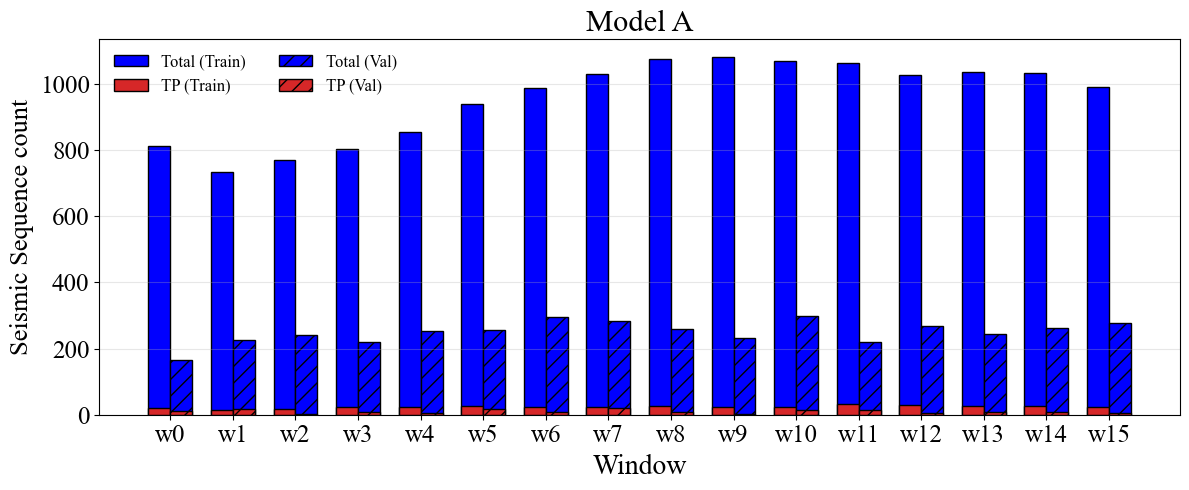

✅ Plots done for model tw48-30dBG_A


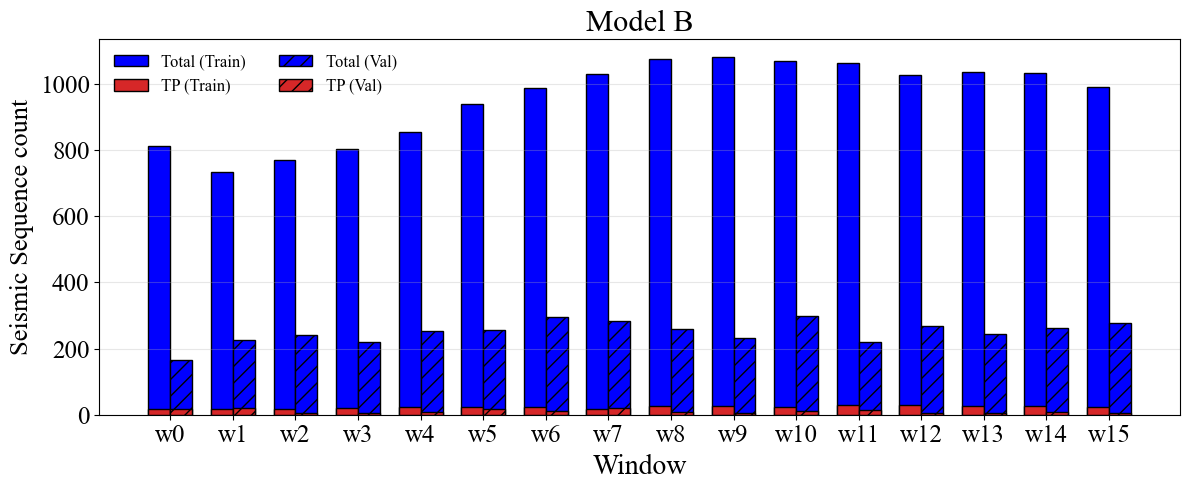

✅ Plots done for model tw48-30dBG_B


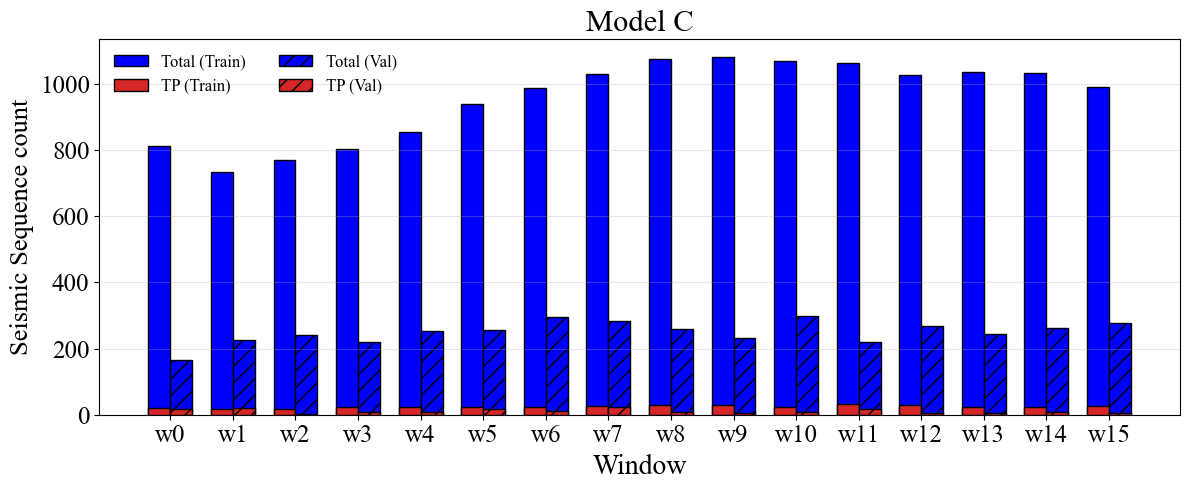

✅ Plots done for model tw48-30dBG_C


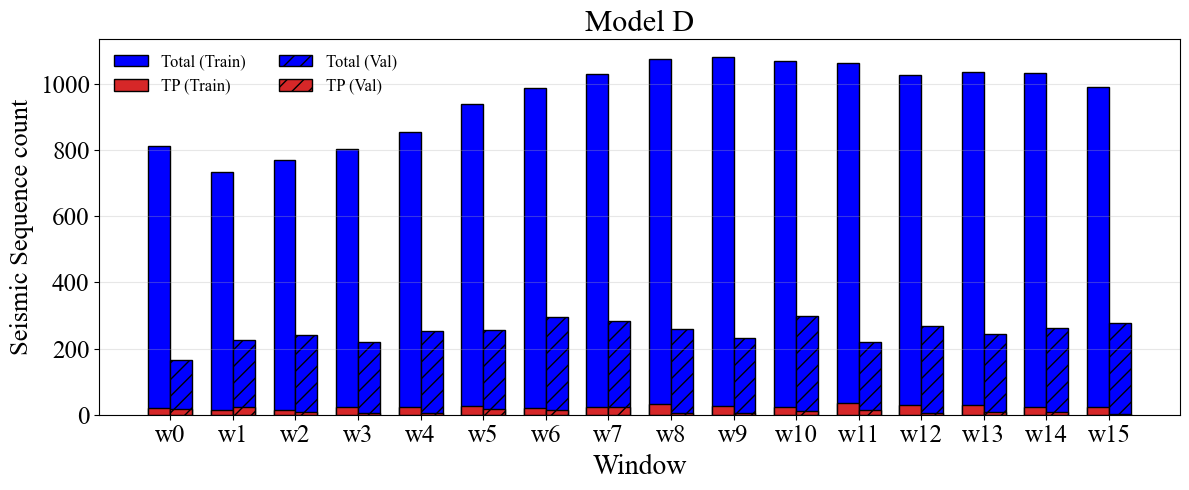

✅ Plots done for model tw48-30dBG_D


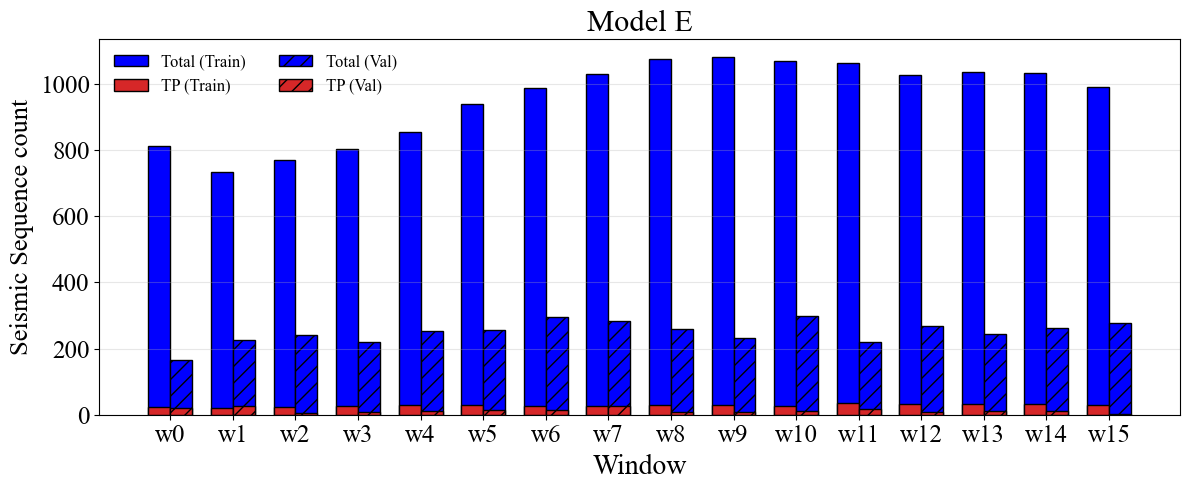

✅ Plots done for model tw48-30dBG_E


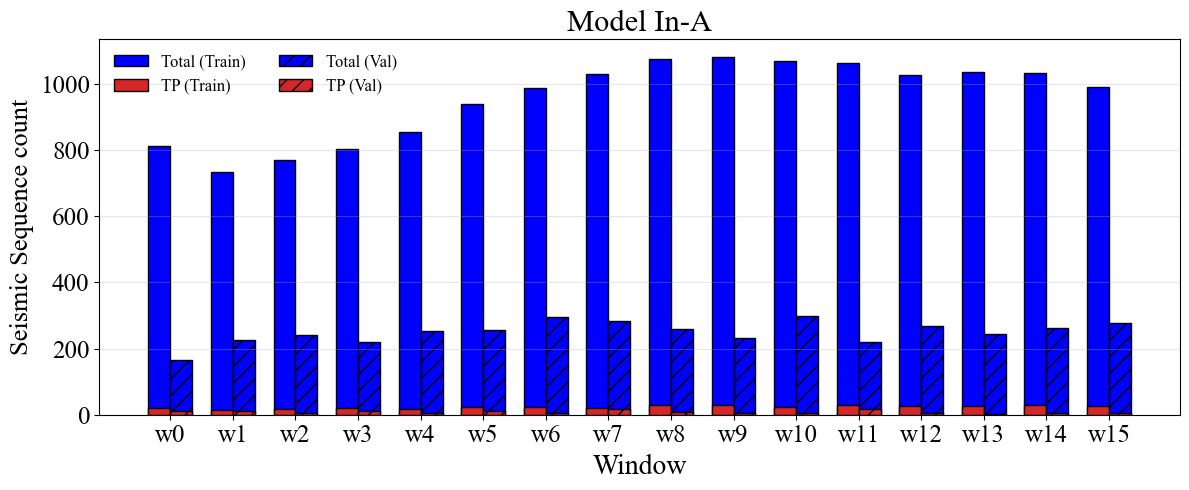

✅ Plots done for model tw48-30dBG_In-A


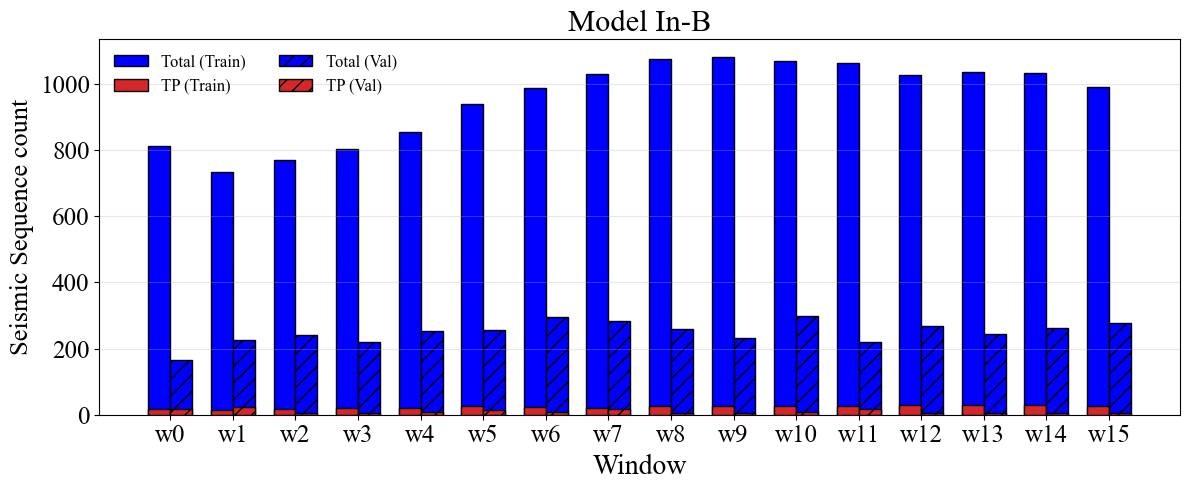

✅ Plots done for model tw48-30dBG_In-B


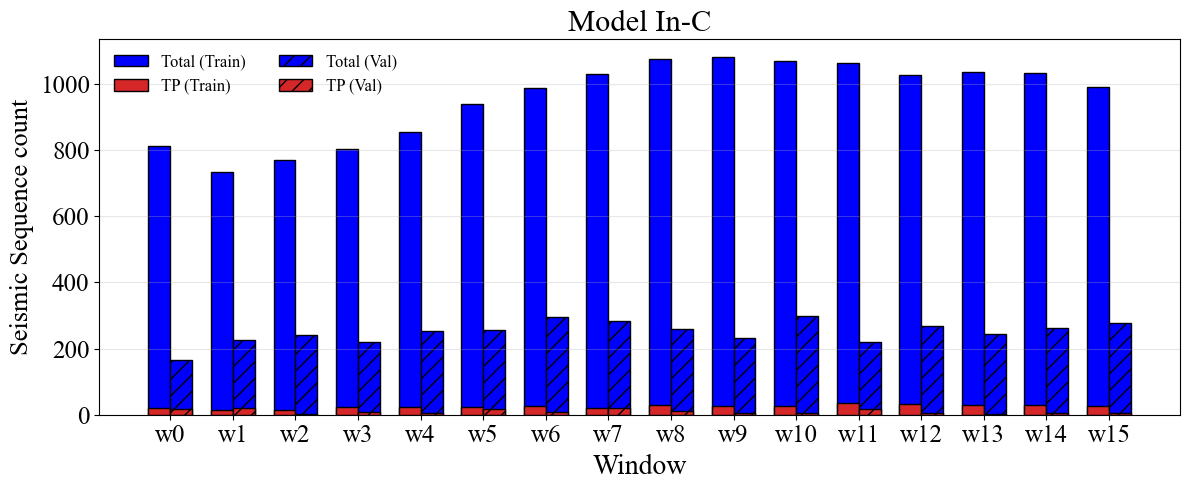

✅ Plots done for model tw48-30dBG_In-C


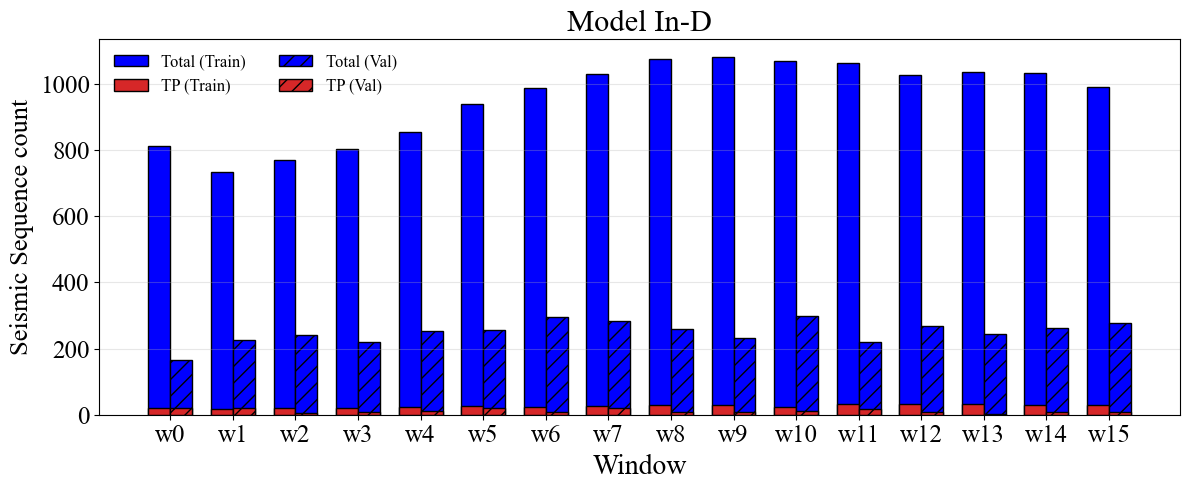

✅ Plots done for model tw48-30dBG_In-D


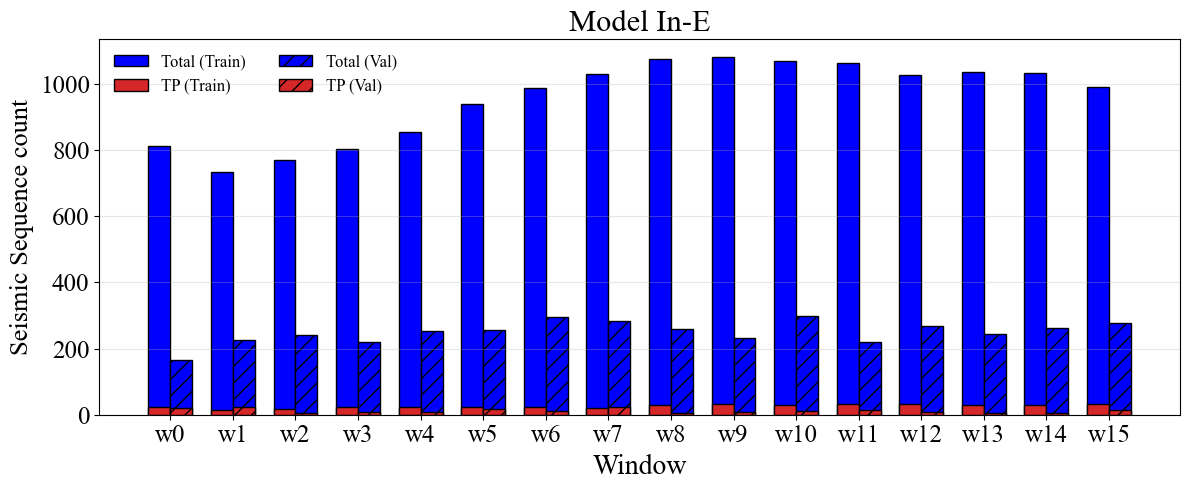

✅ Plots done for model tw48-30dBG_In-E


In [28]:

# --- loop over each Naming in hyperparams ---
for i in range(len(df_hparams)):
    # print(df_hparams.loc[i, 'Naming'])
    m = df_hparams['Naming'][i]
    n =m.split("_")[-1]
    file_path  = fr"{csv_file}\Accuracy_Hp-{m}.csv"

    for window in range(0, 16):
        train_n = pd.read_csv(
            f"C:\\PROJECT-DEMETER\\Demeter_Retrain\\output_base\\Bg_window_data\\summary_df_train_30D-{sw}SW-TW{tw}_w{window}.csv"
        )
        val_n = pd.read_csv(
            f"C:\\PROJECT-DEMETER\\Demeter_Retrain\\output_base\\Bg_window_data\\summary_df_val_30D-{sw}SW-TW{tw}_w{window}.csv"
        )
    # train_n = storm_c['train_seismic_after_storm']
    # val_n = storm_c['val_seismic_after_storm']


    # gt_counts[(window, "Train")] = train_n
        gt_counts[(window, "Train")]   = np.sum(train_n['label'])
        gt_counts[(window, "Val")]   = np.sum(val_n['label'])

    # gt_counts[(window, "Val")]   =val_n
    if not os.path.exists(file_path):
        print(f"⚠️ File not found for {m}: {file_path}")
        continue

    df = pd.read_csv(file_path)

    if "window" not in df.columns:
        df = df.copy()
        df["window"] = (np.arange(len(df)) // 2).astype(int)

    # Now call your plotting functions
    plot_tp_vs_truth(df,gt_counts,f"{n}",   fr"{output_dir}\recall_all-{m}.png")
    # plot_tp_vs_truth(df, storm_c, f"quiet- model_{m}", fr"{output_dir}\Sratio_quiet_{m}.png")
    

    print(f"✅ Plots done for model {m}")


## Function: `q_factor` (Quality Factor) - For Z factor analysis

**What it does:** calculates model-level summary statistics across rolling windows, including average seismic anomaly ratio, propagated error, Q-factor, and Z-like normalized deviation values.

**Main use:** this compresses the rolling-window results into one summary row per model so that models can be compared quantitatively.

**Inputs:**
- `df_hparams`: dataframe containing the model names and hyperparameters.
- `combined_wide`: random-sampling baseline table containing `q2_All`, `99.7_All`, and related columns.
- `mode`: `"all"` or `"quiet"`; selects whether to use normal aggregate columns or storm-corrected/quiet columns.


**Outputs:** returns a results dataframe containing Q-factor values, train/validation Z summaries, average ratios, propagated errors, RST references, model names, and the temporal window.




In [29]:
import os
import numpy as np
import pandas as pd

def z_factor(df_hparams, combined_wide, mode, output_dir):
    q_factors = []
    model_names = []
    model_params = []
    avg_train_list, err_train_list = [], []
    avg_eval_list, err_eval_list  = [], []
    q_tr = []
    tw1=[]
    z_va =[]
    z_tr =[]
   # NEW: train error bar list
    rho_R_all = []
    rho_R99_7_all = []
    z_va_err32 = []   # NEW: val error bar list
    z_tr_err32 = []
    z_va_err68 = []   # NEW: val error bar list
    z_tr_err68 = []

    for m, hp in df_hparams.iterrows():
        file_path = fr"{csv_file}\Retrain_result_Hp_B-{hp['Naming']}.csv"

        if not os.path.exists(file_path):
            print(f"⚠️ File not found for {hp['Naming']}: {file_path}")
            continue
        print(f"Processing {hp['Naming']}")

        mode = mode.lower().strip()
        if mode not in {"all", "quiet"}:
            raise ValueError("mode must be 'all' or 'quiet'")

        # Column/field mapping
        value_col   = "agg_value"     if mode == "all" else "agg_value_sc"
        error_col   = "agg_error"     if mode == "all" else "agg_error_sc"
        ratio_col   = "q2_All"       
        ratio_col2  = "99.7_All"     

        # Load results
        df = pd.read_csv(file_path)
        tr = df[df["split"].str.lower() == "train"].copy()
        va = df[df["split"].str.lower() == "val"].copy()

        # 🔹 For the first 4 models, drop window 0
        if m <= 4:
            tr = tr.iloc[1:16].reset_index(drop=True)
            va = va.iloc[1:16].reset_index(drop=True)
            # print(len(va))
        else :
            tr = tr.iloc[:16].reset_index(drop=True)
            va = va.iloc[:16].reset_index(drop=True)


        # averages
        average_train = np.mean(tr[value_col])
        error_train   = np.sqrt(np.sum(tr[error_col]**2)) / len(tr)

        average_val = np.mean(va[value_col])
        error_val   = np.sqrt(np.sum(va[error_col]**2)) / len(va)

        # reference ratios
        rho_R = float(combined_wide[ratio_col]) 
        rho_R99_7 = float(combined_wide[ratio_col2])

        # --- VAL split ---
        rho_i_val   = va[value_col].to_numpy()
        sigma_i_val = va[error_col].to_numpy()

        # --- TRAIN split ---
        rho_i_tr   = tr[value_col].to_numpy()
        sigma_i_tr = tr[error_col].to_numpy()

    
        
        # z-values (mean of normalized residuals)
        vals_val = (rho_i_val - rho_R) / sigma_i_val
        vals_tr  = (rho_i_tr  - rho_R) / sigma_i_tr

        z   = np.mean(vals_val)
        z_t = np.mean(vals_tr)

        # ---- Percentile-based 1-sigma-like error bars ----
        # For a true 1-sigma percentile interval, use [16, 84].
        # If you REALLY want 32/68, just change [16, 84] -> [32, 68].
        p32_val, p68_val = np.percentile(vals_val, [32, 68])
        p32_tr,  p68_tr  = np.percentile(vals_tr,  [32, 68])
        print(p32_val, p68_val)
        print(np.percentile(vals_val, [0.3, 99.7]))
        print(p32_tr,  p68_tr )
        print(np.percentile(vals_tr,  [0.3, 99.7]))



        # collect
   
        z_va.append(z)
        z_tr.append(z_t)
        z_va_err32.append(p32_val)
        z_tr_err32.append(p32_tr)
        z_va_err68.append(p68_val)
        z_tr_err68.append(p68_tr)
        rho_R99_7_all.append(rho_R99_7)
        rho_R_all.append(rho_R)
        model_names.append(hp['Naming'])
        model_params.append(hp)
        tw1.append(hp['tw'])
        avg_train_list.append(average_train)
        err_train_list.append(error_train)
        avg_eval_list.append(average_val)
        err_eval_list.append(error_val)

    # Assemble results
    results = pd.DataFrame({
        "Naming": model_names,
        "RST_Median": rho_R_all,
        "RST_99.7": rho_R99_7_all,
        f"z_va_{mode}": z_va,
        f"z_tr_{mode}": z_tr,
        f"z_tr_err32_{mode}": z_tr_err32,  
        f"z_va_err32_{mode}": z_va_err32,  
        f"z_tr_err68_{mode}": z_tr_err68,  
        f"z_va_err68_{mode}": z_va_err68,  
        f"avg_train_{mode}": avg_train_list,
        f"err_train_{mode}": err_train_list,
        f"avg_val_{mode}":  avg_eval_list,
        f"err_val_{mode}":  err_eval_list,
        "mode": mode,
        "tw": tw1
    }).reset_index(drop=True)

    # Save
    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(q_dir, f"Qfactor-SW{sw}x{sw}_TW{tw}-{mode}_newz.csv")
    # results.to_csv(csv_path, index=False)
    print(f"✅ Results saved to {csv_path}")

    return results


In [30]:
q_factor_all =z_factor(df_hparams,combined_wide, 'all', output_dir)
q_factor_quiet =z_factor(df_hparams,combined_wide, 'quiet', output_dir)

Processing tw48-30dBG_A
0.02754586725194269 1.5866548880088451
[-2.97206704  2.67479478]
0.9694150717265146 1.883093393201787
[-1.43594982  4.19409459]
Processing tw48-30dBG_B
0.27408375324190115 1.6377388514915128
[-1.48208484  2.95478843]
0.9952927932091388 1.5910416056503396
[-1.07454653  3.08400373]
Processing tw48-30dBG_C
0.6896889185689588 1.9364284620569656
[-2.37870241  3.39688238]
1.2191552176687703 2.029833705576861
[-0.54268454  5.68600809]
Processing tw48-30dBG_D
0.35438811573876083 1.4883631885927897
[-1.43499128  2.95196505]
1.0704470184944233 2.719786406804584
[-1.09321069  6.80387561]
Processing tw48-30dBG_E
0.6702578000040478 2.2074028855679244
[-1.53145246  3.8929397 ]
2.6090895384026735 4.470986172848854
[0.74771446 6.91504036]
Processing tw48-30dBG_In-A
0.1526897778497529 1.2312273585032145
[-1.24267321  3.43916944]
0.5018731701308589 2.3569571924509023
[-1.0766806  4.0145431]
Processing tw48-30dBG_In-B
-0.36611929780331853 1.5477798011768102
[-1.17606175  4.5351445

C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\2102532693.py:64: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rho_R = float(combined_wide[ratio_col])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\2102532693.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rho_R99_7 = float(combined_wide[ratio_col2])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\2102532693.py:64: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rho_R = float(combined_wide[ratio_col])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\2102532693.py:65: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rho_R99_7 = float(combi

In [31]:
q_factor_all

,Naming,RST_Median,RST_99.7,z_va_all,z_tr_all,z_tr_err32_all,z_va_err32_all,z_tr_err68_all,z_va_err68_all,avg_train_all,err_train_all,avg_val_all,err_val_all,mode,tw
0,tw48-30dBG_A,55.0,64.5,0.580345,1.483903,0.969415,0.027546,1.883093,1.586655,65.565855,2.005673,60.655406,3.382304,all,48
1,tw48-30dBG_B,55.0,64.5,0.931967,1.205064,0.995293,0.274084,1.591042,1.637739,64.001267,2.045376,64.962796,3.285515,all,48
2,tw48-30dBG_C,55.0,64.5,1.036936,1.709222,1.219155,0.689689,2.029834,1.936428,67.039413,1.999174,65.378483,3.337975,all,48
3,tw48-30dBG_D,55.0,64.5,0.770513,1.951724,1.070447,0.354388,2.719786,1.488363,67.707816,1.954480,62.597034,3.344383,all,48
4,tw48-30dBG_E,55.0,64.5,1.268752,3.592936,2.609090,0.670258,4.470986,2.207403,77.594455,1.768752,66.375231,2.951503,all,48
5,tw48-30dBG_In-A,55.0,64.5,0.781258,1.397935,0.501873,0.152690,2.356957,1.231227,64.846851,1.960984,63.788591,3.564287,all,48
6,tw48-30dBG_In-B,55.0,64.5,0.940718,1.594145,0.761775,-0.366119,2.206964,1.547780,66.142750,1.942079,63.565100,3.291780,all,48
7,tw48-30dBG_In-C,55.0,64.5,0.706466,2.142019,1.305173,0.016345,2.495537,1.223040,68.596650,1.878005,62.060943,3.458733,all,48
8,tw48-30dBG_In-D,55.0,64.5,1.144518,2.510357,1.220871,0.290350,3.374456,2.104836,71.633193,1.854949,66.115302,3.017082,all,48
9,tw48-30dBG_In-E,55.0,64.5,0.930945,2.514214,1.609555,0.252144,3.229984,1.697393,71.190618,1.845168,64.166255,3.056697,all,48


## Function: `plot_q_results_range`

**What it does:** plots the validation Z-factor summary for each model, using percentile-based vertical ranges and reference threshold lines.

**Main use:** this provides a compact model-comparison plot showing which models have stronger positive deviation from the random baseline.

**Inputs:**
- `results_df`: output dataframe from `q_factor`.
- `mode`: `"all"` or `"quiet"`.
- `tw`: temporal window value.
- `Rst`: RST/random-sampling baseline table.
- `output_dir`: folder where the plot is saved.
- `sw`: optional spatial window label.

**Outputs:** saves and displays a Z-factor range plot.



C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\868922400.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rho_R      = float(Rst["q2_All"])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\868922400.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rho_R99_7  = float(Rst["99.7_All"])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\868922400.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rho_R0_3   = float(Rst["0.3_All"])


['Arial', 'Bahnschrift', 'Calibri', 'Cambria', 'Candara', 'Comic Sans MS', 'Consolas', 'Constantia', 'Corbel', 'Courier New', 'DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif Display', 'Ebrima', 'Franklin Gothic Medium', 'Gabriola', 'Gadugi', 'Georgia', 'HoloLens MDL2 Assets', 'Impact', 'Ink Free', 'Javanese Text', 'Leelawadee UI', 'Lucida Console', 'Lucida Sans Unicode', 'MS Gothic', 'MV Boli', 'Malgun Gothic', 'Microsoft Himalaya', 'Microsoft JhengHei', 'Microsoft New Tai Lue', 'Microsoft PhagsPa', 'Microsoft Sans Serif', 'Microsoft Tai Le', 'Microsoft YaHei', 'Microsoft Yi Baiti', 'MingLiU-ExtB', 'Mongolian Baiti', 'Myanmar Text', 'Nirmala UI', 'Palatino Linotype', 'STIXGeneral', 'STIXNonUnicode', 'STIXSizeFiveSym', 'STIXSizeFourSym', 'STIXSizeOneSym', 'STIXSizeThreeSym', 'STIXSizeTwoSym', 'Sans Serif Collection', 'Segoe Fluent Icons', 'Segoe MDL2 Assets', 'Segoe Print', 'Segoe Script', 'Segoe UI', 'Segoe UI Emoji', 'Segoe UI Historic', 'Segoe 

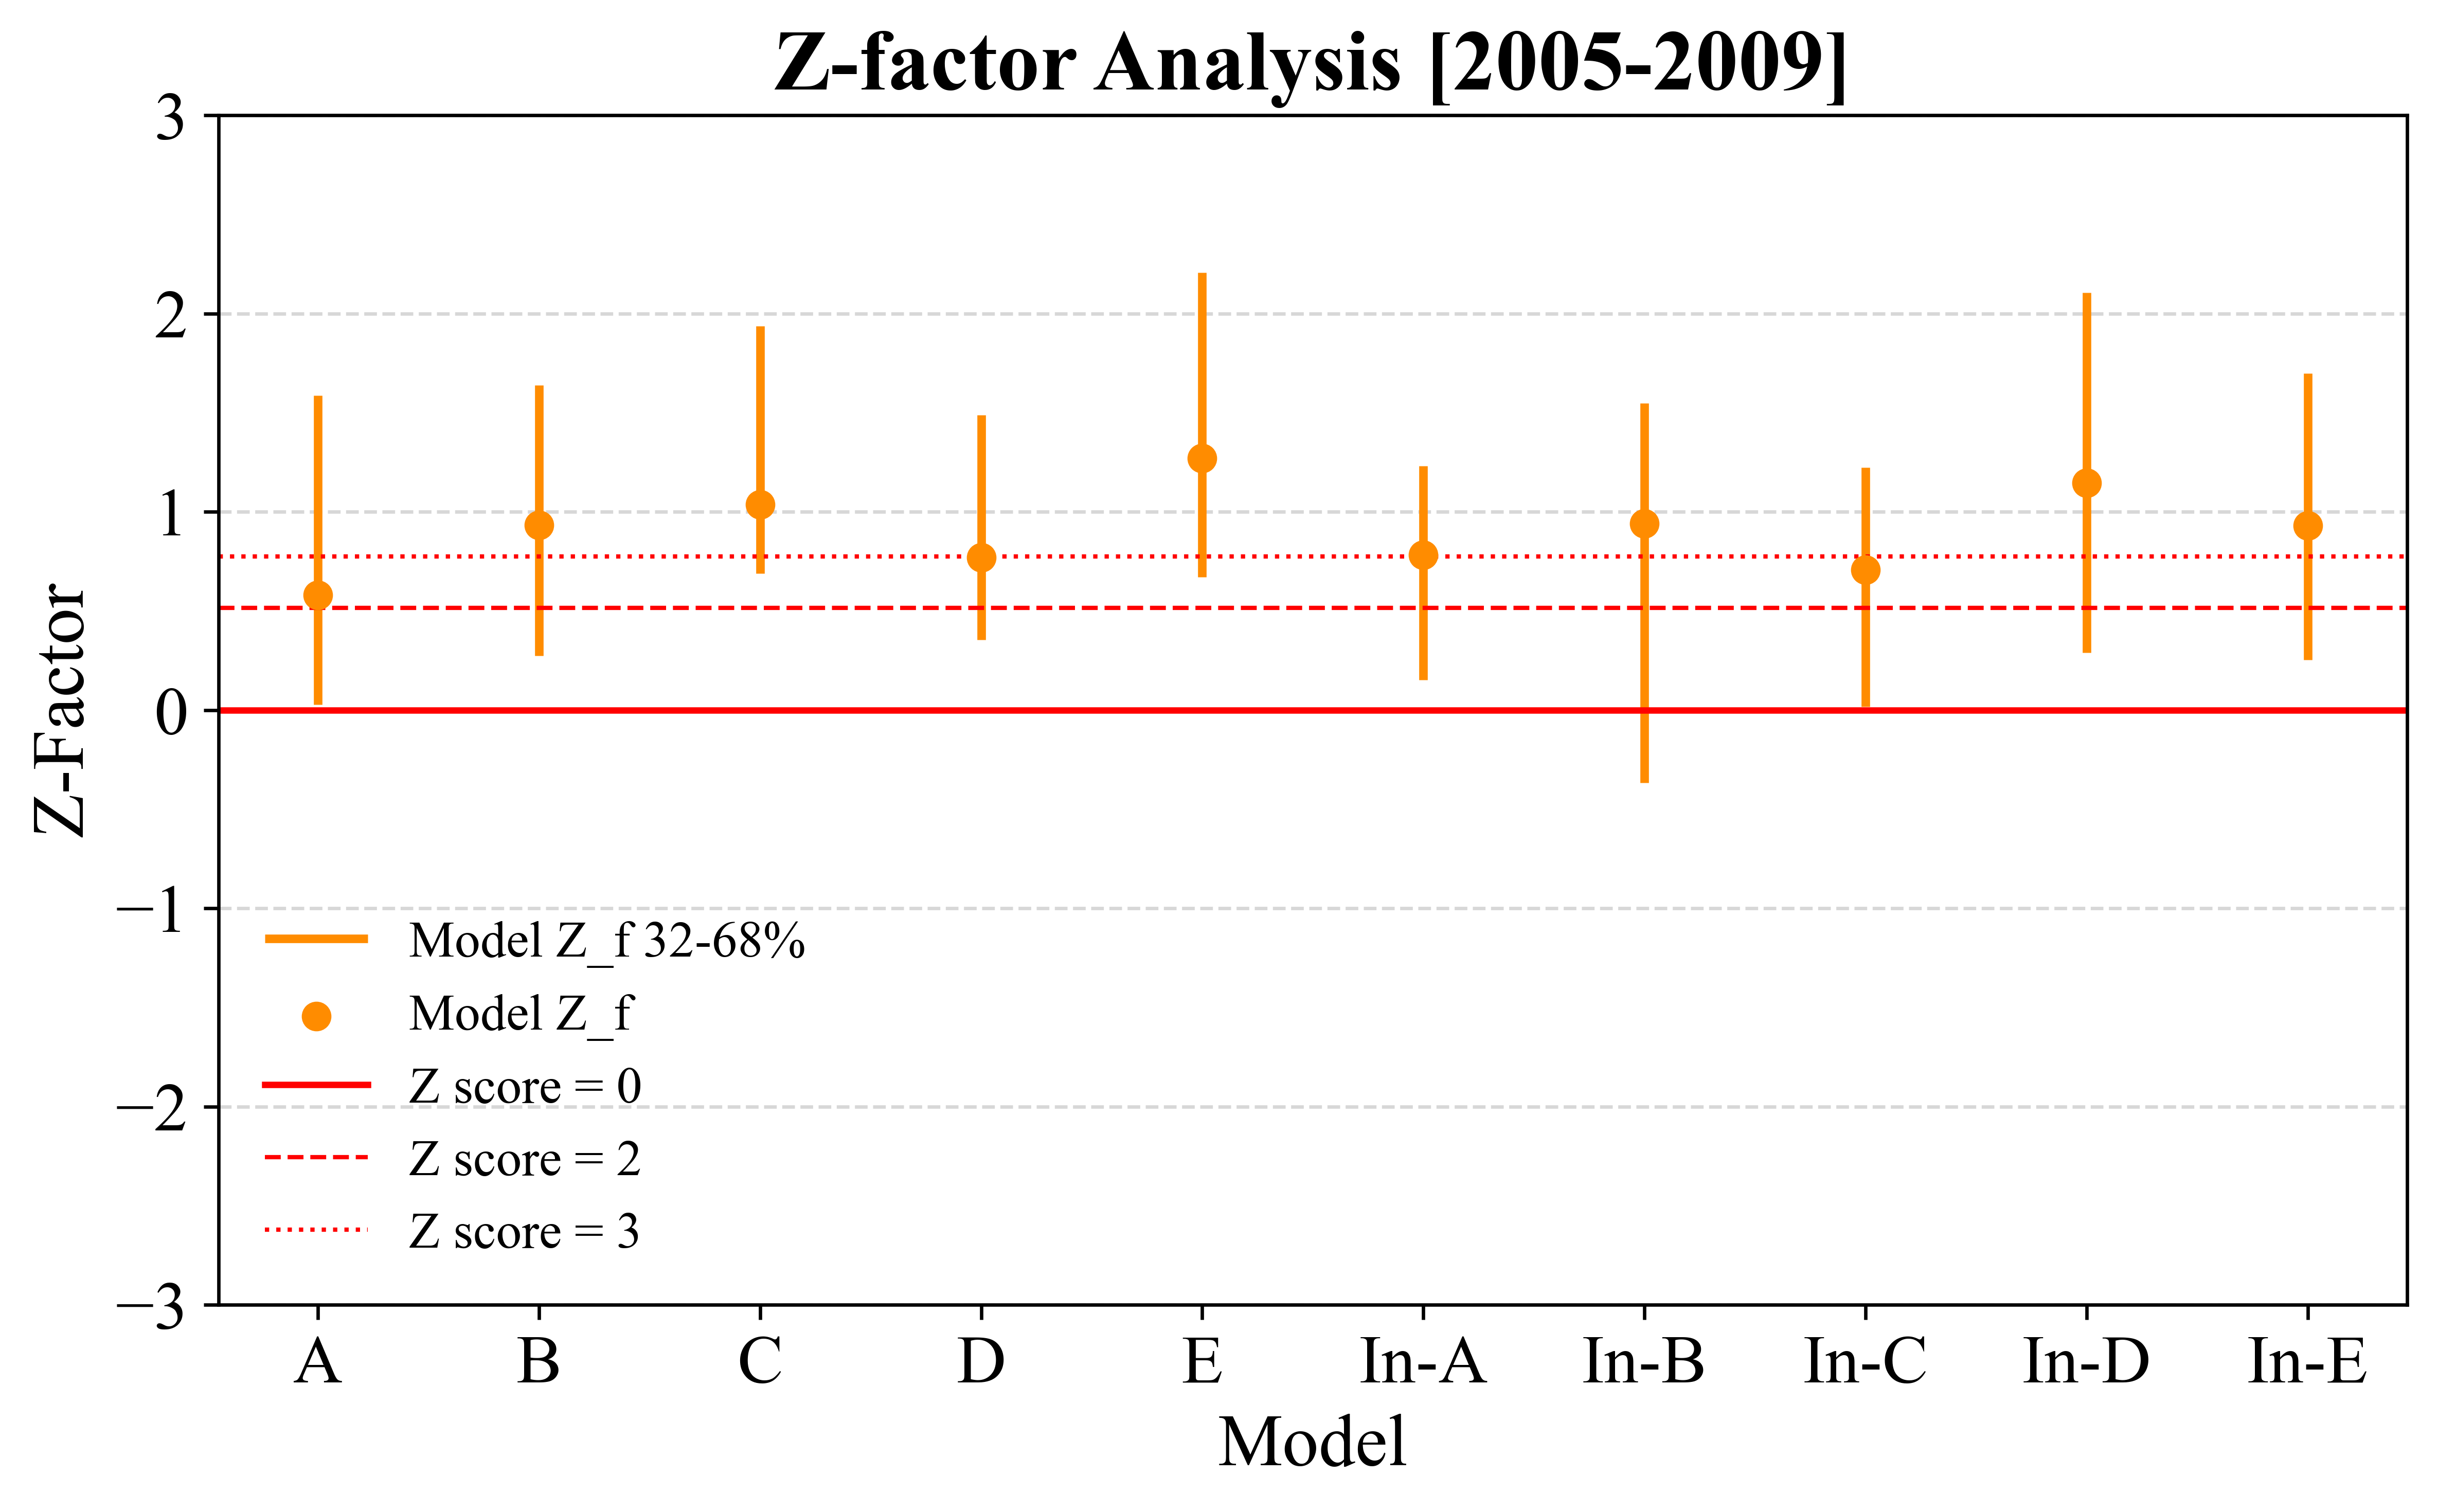

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm
print(sorted(set(f.name for f in fm.fontManager.ttflist)))


# sigma = np.std(percentages)

def plot_q_results_range(results_df, mode, tw, Rst, output_dir=".", sw=None):
    """
    Plot Z-transform ranges (32–68%) for different models with
    publication-style aesthetics and Rst-based reference lines.
    """
    plt.rcParams['font.family'] = 'Times New Roman'

    # ----- Compute reference rhos and z-values -----
    # Rhos are assumed to be stored as fractions; multiply by 100 to convert to %
    rho_R      = float(Rst["q2_All"])  
    rho_R99_7  = float(Rst["99.7_All"]) 
    rho_R0_3   = float(Rst["0.3_All"]) 


    # ----- Data for plotting -----
    y_lower = results_df[f"z_va_err32_{mode}"].values   # 32nd percentile
    y_upper = results_df[f"z_va_err68_{mode}"].values   # 68th percentile
    y       = results_df[f"z_va_{mode}"].values         # central values

    x = np.arange(len(results_df))

    # x tick labels: split by "_" and keep last term only
    naming_raw = results_df["Naming"].astype(str).values
    naming_short = [name.split("_")[-1] for name in naming_raw]

    # ----- Figure settings (publication style) -----
    plt.figure(figsize=(8, 5), dpi=600)

    # main intervals and markers in dark orange
    # label for the range:
    plt.vlines(
        x, y_lower, y_upper,
        color='darkorange', linewidth=2,
        label="Model Z_f 32-68%"
    )
    # label for the median:
    plt.scatter(
        x, y,
        color='darkorange', s=35, zorder=3,
        label="Model Z_f "
    )

    # horizontal reference lines in red, with requested naming
    plt.axhline(
        0.0,
        color='red', linestyle='-', linewidth=1.5,
        label="Z score = 0"
    )

    plt.xticks(
        x,
        naming_short,
        rotation=0,      # no rotation
        ha="center",     # center under the tick (optional)
        fontsize=11
    )

    # x / y labels
    plt.xlabel("Model", fontsize=17)
    plt.ylabel("Z-Factor", fontsize=17)
    z2= 2/np.sqrt(15)
    z3= 3/np.sqrt(15)
    plt.axhline(z2, color="Red", linestyle="--", linewidth=1,
                label="Z score = 2")
    plt.axhline(z3, color="red", linestyle=":", linewidth=1,
                label="Z score = 3")
  

    if sw is not None:
        title = f"Z-factor Analysis [2005-2009]"
    else:
        title = f"WOG_TW{tw}"
    plt.title(title, fontsize=20, fontweight="bold")

    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tick_params(axis='y', labelsize=16)
    plt.tick_params(axis='x', labelsize=16)


    plt.ylim(-3, 3)

    # Legend (no italics, as requested)
    plt.legend(fontsize=12, frameon=False, loc='best')

    plt.tight_layout()

    # filename (kept consistent with previous version)
    fname_sw = f"SW{sw}_" if sw is not None else ""
    fname = f"Z_va_{fname_sw}TW{tw}_{mode}_ranges-poster.png"

    plt.savefig(os.path.join(output_dir, fname), dpi=600, bbox_inches="tight")
    # plt.savefig(r"C:\PROJECT-DEMETER\Paper1\Plots\IEEE\fig_9a.png", dpi=600)
    # plt.savefig(r"C:\PROJECT-DEMETER\Paper1\Plots\IEEE\fig_9a.eps", dpi=600)
    plt.show()

plot_q_results_range(q_factor_all,'all', tw,combined_wide,
                     output_dir=output_dir, sw=sw)


## Function: `plot_train_val_together`

**What it does:** plots the average training and validation seismic anomaly ratios for all models in one figure, with propagated error bars and RST reference lines.

**Main use:** this produces a final consolidated comparison of model performance against the random baseline.

**Inputs:**
- `results_all`: output dataframe from `q_factor`, usually `q_factor_all`.
- `tw`: temporal window to filter.
- `combined_wide`: random-sampling baseline table.
- `output_dir`: intended output folder. Saving is currently commented out.

**Outputs:** displays a combined train/validation model-comparison plot.


C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3424901856.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  q2 = float(combined_wide['q2_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3424901856.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ul = float(combined_wide['99.7_All'])
C:\Users\mbabu\AppData\Local\Temp\ipykernel_28596\3424901856.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  u2 = float(combined_wide['0.3_All'])


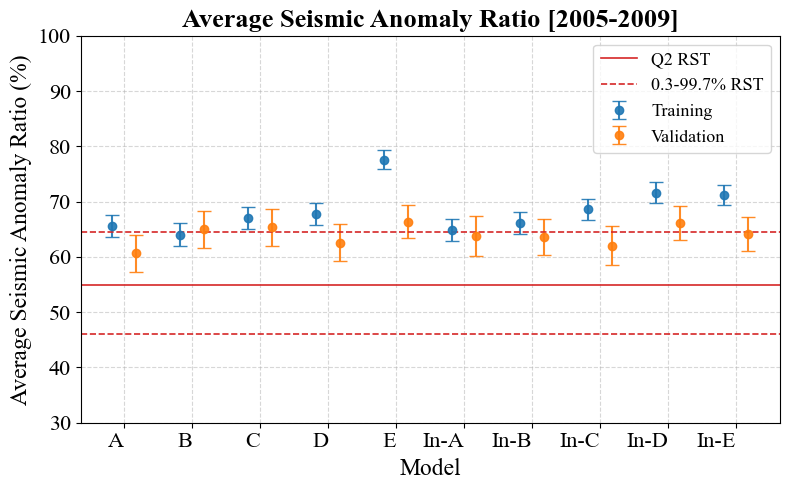

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def plot_train_val_together(results_all, tw, combined_wide, output_dir):

    plt.rcParams['font.family'] = 'Times New Roman'

    """
    Plot training and validation averages (± error) for ALL data
    in a single combined figure with reference lines.
    """

    # Filter for the given time window
    results_all = results_all[results_all['tw'] == tw]
    results_all["newNaming"] = results_all["Naming"].astype(str).str.split("_").str[-1]

    # Reference thresholds
    q2 = float(combined_wide['q2_All']) 
    ul = float(combined_wide['99.7_All']) 
    u2 = float(combined_wide['0.3_All']) 

    # X positions
    x = np.arange(len(results_all))
    width = 0.35

    # --- Plot setup ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(f"Average Seismic Anomaly Ratio [2005-2009]", fontsize=19, weight='bold')

    # --- Training ---
    ax.errorbar(
        x - width/2, results_all["avg_train_all"], yerr=results_all["err_train_all"],
        fmt='o', capsize=5, color="tab:blue", label="Training", alpha=0.9
    )

    # --- Validation ---
    ax.errorbar(
        x + width/2, results_all["avg_val_all"], yerr=results_all["err_val_all"],
        fmt='o', capsize=5, color="tab:orange", label="Validation", alpha=0.9
    )

    # --- Reference lines ---
    ax.axhline(q2, color="tab:red", linestyle="-", lw=1.2, label=r"Q2 RST")
    ax.axhline(ul, color="tab:red", linestyle="--", lw=1.2, label=r"0.3-99.7% RST")
    ax.axhline(u2, color="tab:red", linestyle="--", lw=1.2)
    # --- Formatting ---
    ax.set_xticks(x)
    
    ax.set_xticklabels(results_all["newNaming"], rotation=0, ha="right")
    ax.set_ylabel("Average Seismic Anomaly Ratio (%)", fontsize=17)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=13, loc="best")

    ax.tick_params(axis='both', labelsize=16)
    ax.set_ylim(30,100)
    plt.xlabel('Model',fontsize=17)
    fig.tight_layout()
    # plt.savefig(os.path.join(output_dir, f"Average-train_val-SW{sw}_TW{tw}.png"), dpi=600)
    # plt.savefig(r"C:\PROJECT-DEMETER\Paper1\Plots\IEEE\fig_9b.png", dpi=600)
    # plt.savefig(r"C:\PROJECT-DEMETER\Paper1\Plots\IEEE\fig_9b.eps", dpi=600)
    plt.show()
plot_train_val_together(q_factor_all, tw, combined_wide, output_dir)